In [1]:
from google.cloud import bigquery

# Replace 'mgmt599-priyachanduri' with your actual Project ID if it's different
client = bigquery.Client(project='mgmt599-priyachanduri')

In [10]:
# @title Setup
from google.cloud import bigquery
from google.colab import data_table
import bigframes.pandas as bpd

project = 'mgmt599-priyachanduri' # Project ID inserted based on the query results selected to explore
location = 'US' # Location inserted based on the query results selected to explore
client = bigquery.Client(project=project, location=location)
data_table.enable_dataframe_formatter()

In [14]:
from google.cloud import bigquery
import pandas as pd # Often used to work with query results

# --- Configuration ---
PROJECT_ID = "mgmt599-priyachanduri"
DATASET_ID = "Assignment_1_SuperStore"
TABLE_ID = "Assignment_1_SuperStore"
FULL_TABLE_ID = f"{PROJECT_ID}.{DATASET_ID}.{TABLE_ID}"

# Initialize the BigQuery client
client = bigquery.Client(project=PROJECT_ID)

print(f"--- Connected to BigQuery project: {PROJECT_ID} ---")


# Construct the full table reference
table_ref = client.dataset(DATASET_ID).table(TABLE_ID)

--- Connected to BigQuery project: mgmt599-priyachanduri ---


In [18]:


table = client.get_table(TABLE_ID)  # Make an API request.

print("Table schema:")
for field in table.schema:
    print(
        "├── {}: {}".format(
            field.name,
            field.field_type,
        )
    )

Table schema:
├── order_id: STRING
├── order_date: DATE
├── ship_date: DATE
├── customer: STRING
├── manufactory: STRING
├── product_name: STRING
├── segment: STRING
├── category: STRING
├── subcategory: STRING
├── region: STRING
├── zip: INTEGER
├── city: STRING
├── state: STRING
├── country: STRING
├── discount: FLOAT
├── profit: FLOAT
├── quantity: INTEGER
├── sales: FLOAT
├── profit_margin: FLOAT


In [23]:
from google.colab import auth
auth.authenticate_user()

In [24]:
from google.cloud import bigquery
import pandas as pd # Often used to work with query results
from google.colab import auth # Import the authentication library

# Authenticate to Google Cloud
auth.authenticate_user()


# --- Configuration ---
PROJECT_ID = "mgmt599-priyachanduri"
DATASET_ID = "Assignment_1_SuperStore"
TABLE_ID = "Assignment_1_SuperStore"
FULL_TABLE_ID = f"{PROJECT_ID}.{DATASET_ID}.{TABLE_ID}"

# Initialize the BigQuery client
client = bigquery.Client(project=PROJECT_ID)


print(f"--- Connected to BigQuery project: {PROJECT_ID} ---")


# Construct the full table reference
table_ref = client.dataset(DATASET_ID).table(TABLE_ID) # Use DATASET_ID and TABLE_ID

--- Connected to BigQuery project: mgmt599-priyachanduri ---


In [26]:
query = f"""
SELECT COUNT(*)
FROM `{PROJECT_ID}.{DATASET_ID}.{TABLE_ID}`
"""

query_job = client.query(query) # Use the existing client object
row_count_sql = query_job.result().to_dataframe().iloc[0, 0]

print(f"Record count (using SQL query): {row_count_sql}")

Record count (using SQL query): 9994


In [33]:
%%bigquery --project mgmt599-priyachanduri
SELECT SUM(sales) AS TotalSales
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`

Query is running:   0%|          |

Downloading:   0%|          |

,TotalSales
0,2.297201e+06


In [36]:
%%bigquery --project mgmt599-priyachanduri
SELECT SUM(profit) AS TotalProfit
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`

Query is running:   0%|          |

Downloading:   0%|          |

,TotalProfit
0,286397.0217


In [38]:
%%bigquery --project mgmt599-priyachanduri
SELECT AVG(sales) AS AverageOrderValue
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`

Query is running:   0%|          |

Downloading:   0%|          |

,AverageOrderValue
0,229.858001


In [44]:
%%bigquery --project mgmt599-priyachanduri
SELECT
    category,
    SUM(sales) AS TotalSales,
    SUM(profit) AS TotalProfit,
    AVG(profit_margin) AS AverageProfitMargin
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY category
ORDER BY TotalSales DESC

Query is running:   0%|          |

Downloading:   0%|          |

,category,TotalSales,TotalProfit,AverageProfitMargin
0,Technology,836154.0330,145454.9481,0.156138
1,Furniture,741999.7953,18451.2728,0.038784
2,Office Supplies,719047.0320,122490.8008,0.138030


In [46]:
%%bigquery --project mgmt599-priyachanduri
SELECT
    region,
    SUM(sales) AS TotalSales,
    SUM(profit) AS TotalProfit
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY region
ORDER BY TotalSales DESC

Query is running:   0%|          |

Downloading:   0%|          |

,region,TotalSales,TotalProfit
0,West,725457.8245,108418.4489
1,East,678781.2400,91522.7800
2,Central,501239.8908,39706.3625
3,South,391721.9050,46749.4303


In [39]:
%%bigquery --project mgmt599-priyachanduri
SELECT AVG(profit) AS AverageProfit
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`

Query is running:   0%|          |

Downloading:   0%|          |

,AverageProfit
0,28.656896


In [40]:
%%bigquery --project mgmt599-priyachanduri
SELECT region, SUM(sales) AS RegionalSales
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY region
ORDER BY RegionalSales DESC

Query is running:   0%|          |

Downloading:   0%|          |

,region,RegionalSales
0,West,725457.8245
1,East,678781.2400
2,Central,501239.8908
3,South,391721.9050


# •	What drives product profitability?

In [47]:
%%bigquery --project mgmt599-priyachanduri
SELECT
    product_name,
    AVG(sales) AS AverageSalesPerOrder,
    AVG(profit) AS AverageProfitPerOrder,
    SUM(sales) AS TotalSales,
    SUM(profit) AS TotalProfit
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY product_name
ORDER BY TotalProfit DESC
LIMIT 10 -- Limit to the top 10 most profitable products

Query is running:   0%|          |

Downloading:   0%|          |

,product_name,AverageSalesPerOrder,AverageProfitPerOrder,TotalSales,TotalProfit
0,Canon imageCLASS 2200 Advanced Copier,12319.964800,5039.985600,61599.824,25199.9280
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,2745.338400,775.303900,27453.384,7753.0390
2,Hewlett Packard LaserJet 3310 Copier,2354.960750,872.985450,18839.686,6983.8836
3,Canon PC1060 Personal Laser Copier,2904.958500,1142.733675,11619.834,4570.9347
4,HP Designjet T520 Inkjet Large Format Printer ...,6124.965000,1364.992200,18374.895,4094.9766
5,Ativa V4110MDD Micro-Cut Shredder,3849.945000,1886.473050,7699.890,3772.9461
6,"3D Systems Cube Printer, 2nd Generation, Magenta",7149.945000,1858.985700,14299.890,3717.9714
7,Plantronics Savi W720 Multi-Device Wireless He...,1338.184286,528.040286,9367.290,3696.2820
8,Ibico EPK-21 Electric Binding System,5291.972000,1115.094100,15875.916,3345.2823
9,Zebra ZM400 Thermal Label Printer,3482.850000,1671.768000,6965.700,3343.5360


In [48]:
%%bigquery --project mgmt599-priyachanduri
SELECT
    discount,
    AVG(profit) AS AverageProfit,
    AVG(sales) AS AverageSales
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY discount
ORDER BY discount

Query is running:   0%|          |

Downloading:   0%|          |

,discount,AverageProfit,AverageSales
0,0.00,66.900292,226.742074
1,0.10,96.055074,578.397351
2,0.15,27.288298,529.971567
3,0.20,24.702572,209.076940
4,0.30,-45.679636,454.742974
5,0.32,-88.560656,536.794770
6,0.40,-111.927429,565.134874
7,0.45,-226.646464,498.634000
8,0.50,-310.703456,892.705152
9,0.60,-43.077212,48.150000


In [49]:
%%bigquery --project mgmt599-priyachanduri
SELECT
    quantity,
    AVG(profit) AS AverageProfitPerOrder,
    AVG(sales) AS AverageSalesPerOrder
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY quantity
ORDER BY quantity
LIMIT 10 -- Limit to reasonable quantities

Query is running:   0%|          |

Downloading:   0%|          |

,quantity,AverageProfitPerOrder,AverageSalesPerOrder
0,1,8.276396,59.234632
1,2,16.006831,120.354488
2,3,23.667715,175.201578
3,4,37.131310,271.764059
4,5,40.257394,337.936339
5,6,18.051517,362.101960
6,7,56.579163,395.888393
7,8,42.244342,458.210802
8,9,68.557716,498.083683
9,10,35.862404,422.046737


# •	Where should we focus product strategy?

In [51]:
%%bigquery --project mgmt599-priyachanduri
SELECT
    category,
    SUM(sales) AS TotalSales,
    SUM(profit) AS TotalProfit,
    AVG(profit_margin) AS AverageProfitMargin
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY category
ORDER BY TotalSales DESC

Query is running:   0%|          |

Downloading:   0%|          |

,category,TotalSales,TotalProfit,AverageProfitMargin
0,Technology,836154.0330,145454.9481,0.156138
1,Furniture,741999.7953,18451.2728,0.038784
2,Office Supplies,719047.0320,122490.8008,0.138030


In [55]:
%%bigquery --project mgmt599-priyachanduri
SELECT
    region,
    SUM(sales) AS TotalSales,
    SUM(profit) AS TotalProfit
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY region
ORDER BY TotalSales DESC

Query is running:   0%|          |

Downloading:   0%|          |

,region,TotalSales,TotalProfit
0,West,725457.8245,108418.4489
1,East,678781.2400,91522.7800
2,Central,501239.8908,39706.3625
3,South,391721.9050,46749.4303


In [54]:
%%bigquery --project mgmt599-priyachanduri
SELECT
    product_name,
    AVG(sales) AS AverageSalesPerOrder,
    AVG(profit) AS AverageProfitPerOrder,
    SUM(sales) AS TotalSales,
    SUM(profit) AS TotalProfit
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY product_name
ORDER BY TotalProfit DESC
LIMIT 10 -- Limit to the top 10 most profitable products

Query is running:   0%|          |

Downloading:   0%|          |

,product_name,AverageSalesPerOrder,AverageProfitPerOrder,TotalSales,TotalProfit
0,Canon imageCLASS 2200 Advanced Copier,12319.964800,5039.985600,61599.824,25199.9280
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,2745.338400,775.303900,27453.384,7753.0390
2,Hewlett Packard LaserJet 3310 Copier,2354.960750,872.985450,18839.686,6983.8836
3,Canon PC1060 Personal Laser Copier,2904.958500,1142.733675,11619.834,4570.9347
4,HP Designjet T520 Inkjet Large Format Printer ...,6124.965000,1364.992200,18374.895,4094.9766
5,Ativa V4110MDD Micro-Cut Shredder,3849.945000,1886.473050,7699.890,3772.9461
6,"3D Systems Cube Printer, 2nd Generation, Magenta",7149.945000,1858.985700,14299.890,3717.9714
7,Plantronics Savi W720 Multi-Device Wireless He...,1338.184286,528.040286,9367.290,3696.2820
8,Ibico EPK-21 Electric Binding System,5291.972000,1115.094100,15875.916,3345.2823
9,Zebra ZM400 Thermal Label Printer,3482.850000,1671.768000,6965.700,3343.5360


# •	Product profitability analysis

In [57]:
%%bigquery --project mgmt599-priyachanduri
SELECT
    subcategory,
    SUM(sales) AS TotalSales,
    SUM(profit) AS TotalProfit,
    AVG(profit_margin) AS AverageProfitMargin
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY subcategory
ORDER BY TotalProfit DESC

Query is running:   0%|          |

Downloading:   0%|          |

,subcategory,TotalSales,TotalProfit,AverageProfitMargin
0,Copiers,149528.0300,55617.8249,0.317194
1,Phones,330007.0540,44515.7306,0.119222
2,Accessories,167380.3180,41936.6357,0.218210
3,Paper,78479.2060,34053.5693,0.425600
4,Binders,203412.7330,30221.7633,-0.199595
5,Chairs,328449.1030,26590.1663,0.043900
6,Storage,223843.6080,21278.8264,0.089113
7,Appliances,107532.1610,18138.0054,-0.156869
8,Furnishings,91705.1640,13059.1436,0.137066
9,Envelopes,16476.4020,6964.1767,0.423140


In [58]:
%%bigquery --project mgmt599-priyachanduri
SELECT
    FORMAT_DATE('%Y-%m', order_date) AS OrderMonth,
    AVG(sales) AS AverageMonthlySalesPerOrder,
    AVG(profit) AS AverageMonthlyProfitPerOrder
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY FORMAT_DATE('%Y-%m', order_date)
ORDER BY OrderMonth

Query is running:   0%|          |

Downloading:   0%|          |

,OrderMonth,AverageMonthlySalesPerOrder,AverageMonthlyProfitPerOrder
0,2019-01,180.213861,31.015072
1,2019-02,98.258522,18.745835
2,2019-03,354.719803,3.176624
3,2019-04,209.595148,25.843224
4,2019-05,193.838418,22.448439
5,2019-06,256.260204,36.863144
6,2019-07,237.387364,-5.884494
7,2019-08,182.414827,34.758856
8,2019-09,305.139369,31.074998
9,2019-10,197.820082,21.687153


# •	Category performance comparison

In [62]:
%%bigquery --project mgmt599-priyachanduri
SELECT
    category,
    SUM(sales) AS TotalSales
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY category
ORDER BY TotalSales DESC

Query is running:   0%|          |

Downloading:   0%|          |

,category,TotalSales
0,Technology,836154.0330
1,Furniture,741999.7953
2,Office Supplies,719047.0320


In [63]:
%%bigquery --project mgmt599-priyachanduri
SELECT
    customer,
    SUM(sales) AS TotalSales,
    COUNT(DISTINCT order_id) AS NumberOfOrders
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY customer
ORDER BY TotalSales DESC
LIMIT 10

Query is running:   0%|          |

Downloading:   0%|          |

,customer,TotalSales,NumberOfOrders
0,Sean Miller,25043.050,5
1,Tamara Chand,19052.218,5
2,Raymond Buch,15117.339,6
3,Tom Ashbrook,14595.620,4
4,Adrian Barton,14473.571,10
5,Ken Lonsdale,14175.229,12
6,Sanjit Chand,14142.334,9
7,Hunter Lopez,12873.298,6
8,Sanjit Engle,12209.438,11
9,Christopher Conant,12129.072,5


In [64]:
%%bigquery --project mgmt599-priyachanduri
SELECT
    customer,
    SUM(profit) AS TotalProfit,
    COUNT(DISTINCT order_id) AS NumberOfOrders
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY customer
ORDER BY TotalProfit DESC
LIMIT 10

Query is running:   0%|          |

Downloading:   0%|          |

,customer,TotalProfit,NumberOfOrders
0,Tamara Chand,8981.3239,5
1,Raymond Buch,6976.0959,6
2,Sanjit Chand,5757.4119,9
3,Hunter Lopez,5622.4292,6
4,Adrian Barton,5444.8055,10
5,Tom Ashbrook,4703.7883,4
6,Christopher Martinez,3899.8904,4
7,Keith Dawkins,3038.6254,12
8,Andy Reiter,2884.6208,6
9,Daniel Raglin,2869.0760,8


In [65]:
%%bigquery --project mgmt599-priyachanduri
SELECT
    discount,
    AVG(profit) AS AverageProfit,
    AVG(sales) AS AverageSales
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY discount
ORDER BY discount

Query is running:   0%|          |

Downloading:   0%|          |

,discount,AverageProfit,AverageSales
0,0.00,66.900292,226.742074
1,0.10,96.055074,578.397351
2,0.15,27.288298,529.971567
3,0.20,24.702572,209.076940
4,0.30,-45.679636,454.742974
5,0.32,-88.560656,536.794770
6,0.40,-111.927429,565.134874
7,0.45,-226.646464,498.634000
8,0.50,-310.703456,892.705152
9,0.60,-43.077212,48.150000


# Task
Generate a PDF document containing visualizations of the results from the following SQL queries, each executed using `%%bigquery --project mgmt599-priyachanduri`:
1.  `SELECT category, SUM(sales) AS total_sales FROM dataset GROUP BY category ORDER BY total_sales DESC`
2.  `SELECT product, SUM(profit) AS total_profit FROM dataset GROUP BY product ORDER BY total_profit DESC`
3.  `SELECT category, AVG(discount) AS average_discount, AVG(profit) AS average_profit FROM dataset GROUP BY category`
4.  `SELECT customer_segment, COUNT(*) AS number_of_customers, AVG(sales) AS average_sales_per_customer FROM dataset GROUP BY customer_segment`
5.  `SELECT discount, AVG(sales) AS average_sales, AVG(profit) AS average_profit FROM dataset GROUP BY discount ORDER BY discount`

## Identify sql queries

### Subtask:
List all the SQL queries that have been executed and whose results should be visualized.


## Execute sql queries and store results

### Subtask:
For each identified SQL query, execute it using the `%%bigquery` magic command and store the results in a pandas DataFrame.


**Reasoning**:
The subtask requires executing five SQL queries using the `%%bigquery` magic command and storing the results in separate pandas DataFrames. I will execute the first query and store the result in a DataFrame.



In [66]:
%%bigquery --project mgmt599-priyachanduri df_category_sales
SELECT category, SUM(sales) AS total_sales
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY category
ORDER BY total_sales DESC

ValueError: Unrecognized input, are option values correct? Error details: Unexpected input at position 32: df_category_sales

**Reasoning**:
The previous command failed because the syntax for the `%%bigquery` magic command to store results in a variable was incorrect. The variable name should be placed before the `--project` argument. I will correct the syntax and execute the first query again.



In [67]:
%%bigquery df_category_sales --project mgmt599-priyachanduri
SELECT category, SUM(sales) AS total_sales
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY category
ORDER BY total_sales DESC

Query is running:   0%|          |

Downloading:   0%|          |

**Reasoning**:
I have successfully executed the first query and stored the result in `df_category_sales`. Now I will execute the second query to get total profit by product and store the result in a DataFrame named `df_product_profit`.



In [68]:
%%bigquery df_product_profit --project mgmt599-priyachanduri
SELECT product_name, SUM(profit) AS total_profit
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY product_name
ORDER BY total_profit DESC

Query is running:   0%|          |

Downloading:   0%|          |

**Reasoning**:
I have executed the first two queries. Now I will execute the third query to get average discount and average profit by category and store the result in a DataFrame named `df_category_discount_profit`.



In [69]:
%%bigquery df_category_discount_profit --project mgmt599-priyachanduri
SELECT category, AVG(discount) AS average_discount, AVG(profit) AS average_profit
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY category

Query is running:   0%|          |

Downloading:   0%|          |

**Reasoning**:
I have executed the first three queries. Now I will execute the fourth query to get the number of customers and average sales per customer by customer segment and store the result in a DataFrame named `df_customer_segment`.



In [70]:
%%bigquery df_customer_segment --project mgmt599-priyachanduri
SELECT segment, COUNT(*) AS number_of_customers, AVG(sales) AS average_sales_per_customer
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY segment

Query is running:   0%|          |

Downloading:   0%|          |

**Reasoning**:
I have executed the first four queries. Now I will execute the fifth query to get average sales and average profit by discount and store the result in a DataFrame named `df_discount_sales_profit`. This completes the subtask of executing all five queries and storing the results in DataFrames.



In [71]:
%%bigquery df_discount_sales_profit --project mgmt599-priyachanduri
SELECT discount, AVG(sales) AS average_sales, AVG(profit) AS average_profit
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY discount
ORDER BY discount

Query is running:   0%|          |

Downloading:   0%|          |

## Generate visualizations

### Subtask:
For each DataFrame, create an appropriate visualization (e.g., bar chart for categorical data, line chart for time-series data) using a suitable plotting library like Matplotlib or Seaborn.


**Reasoning**:
Import the necessary plotting libraries to create visualizations for the dataframes.



In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

**Reasoning**:
Create a bar plot for total sales by category from the df_category_sales dataframe.



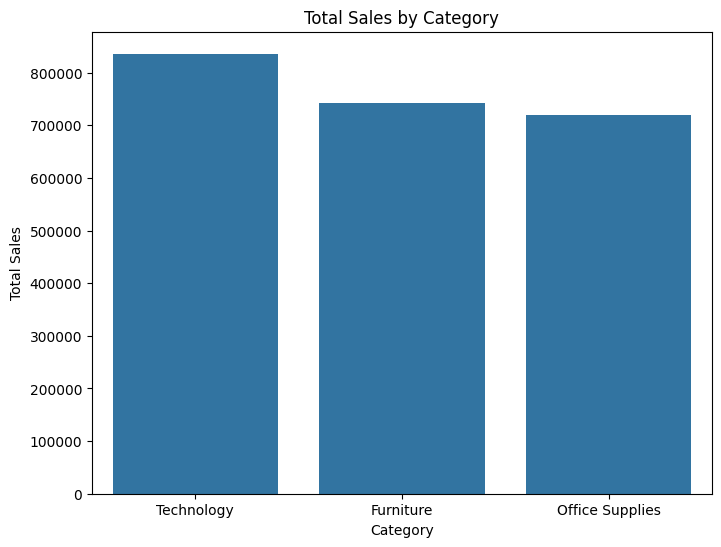

In [73]:
plt.figure(figsize=(8, 6))
sns.barplot(x='category', y='total_sales', data=df_category_sales)
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.show()

**Reasoning**:
Create a bar plot for total profit of the top 10 products from the df_product_profit dataframe to visualize product profitability.



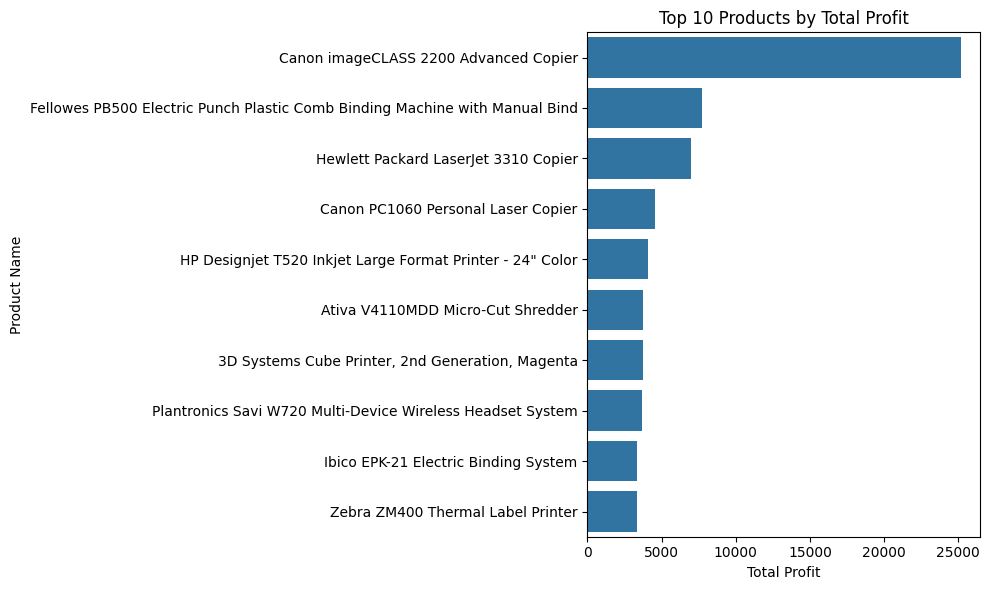

In [74]:
df_product_profit_top10 = df_product_profit.head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x='total_profit', y='product_name', data=df_product_profit_top10)
plt.title('Top 10 Products by Total Profit')
plt.xlabel('Total Profit')
plt.ylabel('Product Name')
plt.tight_layout()
plt.show()

**Reasoning**:
Create bar plots to visualize the average discount and average profit by category from the df_category_discount_profit dataframe.



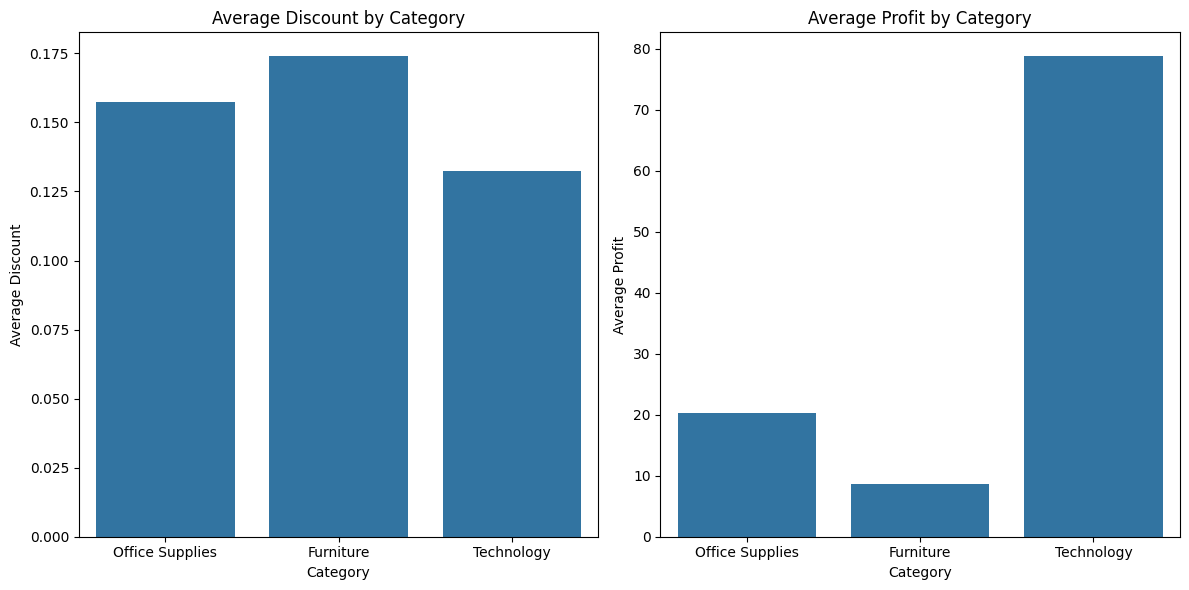

In [75]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.barplot(x='category', y='average_discount', data=df_category_discount_profit)
plt.title('Average Discount by Category')
plt.xlabel('Category')
plt.ylabel('Average Discount')

plt.subplot(1, 2, 2)
sns.barplot(x='category', y='average_profit', data=df_category_discount_profit)
plt.title('Average Profit by Category')
plt.xlabel('Category')
plt.ylabel('Average Profit')

plt.tight_layout()
plt.show()

**Reasoning**:
Create bar plots to visualize the number of customers and average sales per customer by segment from the df_customer_segment dataframe.



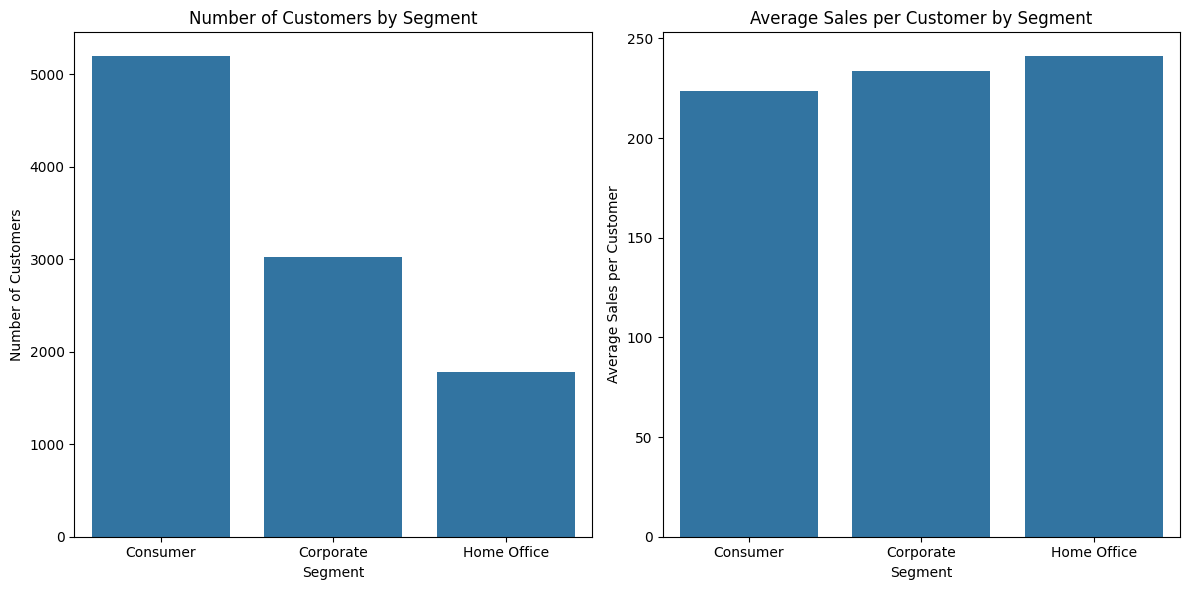

In [76]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.barplot(x='segment', y='number_of_customers', data=df_customer_segment)
plt.title('Number of Customers by Segment')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')

plt.subplot(1, 2, 2)
sns.barplot(x='segment', y='average_sales_per_customer', data=df_customer_segment)
plt.title('Average Sales per Customer by Segment')
plt.xlabel('Segment')
plt.ylabel('Average Sales per Customer')

plt.tight_layout()
plt.show()

**Reasoning**:
Create plots to visualize the relationship between discount, average sales, and average profit from the df_discount_sales_profit dataframe. Scatter plots are suitable for showing the relationship between these numerical variables.



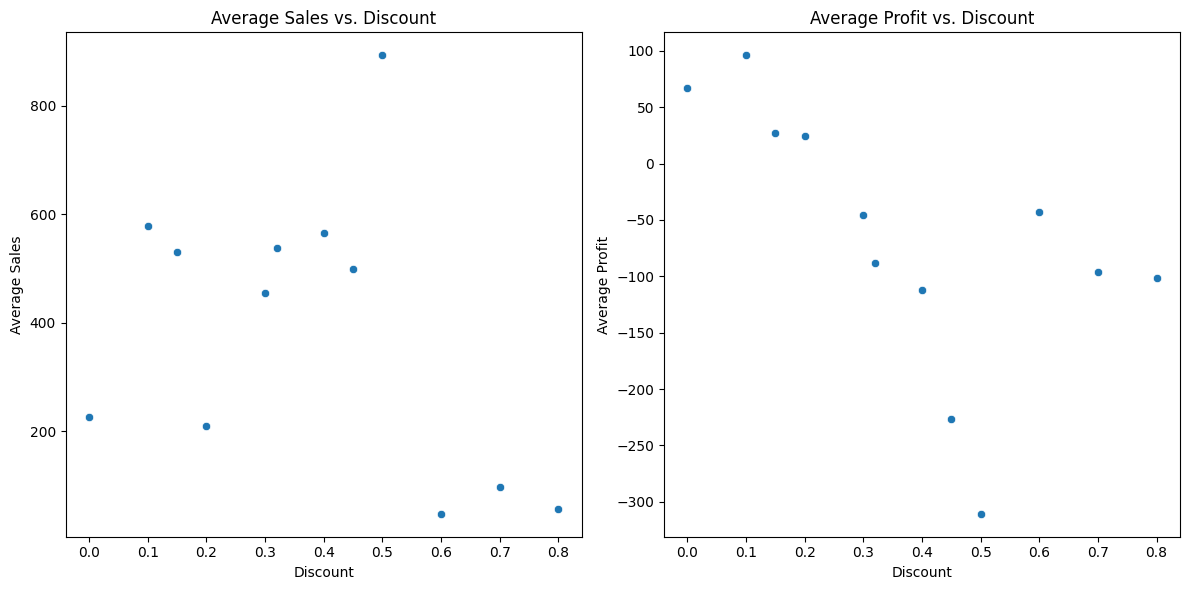

In [77]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x='discount', y='average_sales', data=df_discount_sales_profit)
plt.title('Average Sales vs. Discount')
plt.xlabel('Discount')
plt.ylabel('Average Sales')

plt.subplot(1, 2, 2)
sns.scatterplot(x='discount', y='average_profit', data=df_discount_sales_profit)
plt.title('Average Profit vs. Discount')
plt.xlabel('Discount')
plt.ylabel('Average Profit')

plt.tight_layout()
plt.show()

## Save visualizations

### Subtask:
Save each generated visualization as an image file (e.g., PNG).


**Reasoning**:
Iterate through each generated plot and save it as a PNG file.



In [78]:
plt.figure(figsize=(8, 6))
sns.barplot(x='category', y='total_sales', data=df_category_sales)
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.savefig('total_sales_by_category.png', bbox_inches='tight')
plt.close()

df_product_profit_top10 = df_product_profit.head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x='total_profit', y='product_name', data=df_product_profit_top10)
plt.title('Top 10 Products by Total Profit')
plt.xlabel('Total Profit')
plt.ylabel('Product Name')
plt.tight_layout()
plt.savefig('top_10_products_by_profit.png', bbox_inches='tight')
plt.close()

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.barplot(x='category', y='average_discount', data=df_category_discount_profit)
plt.title('Average Discount by Category')
plt.xlabel('Category')
plt.ylabel('Average Discount')
plt.subplot(1, 2, 2)
sns.barplot(x='category', y='average_profit', data=df_category_discount_profit)
plt.title('Average Profit by Category')
plt.xlabel('Category')
plt.ylabel('Average Profit')
plt.tight_layout()
plt.savefig('category_discount_profit.png', bbox_inches='tight')
plt.close()

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.barplot(x='segment', y='number_of_customers', data=df_customer_segment)
plt.title('Number of Customers by Segment')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.subplot(1, 2, 2)
sns.barplot(x='segment', y='average_sales_per_customer', data=df_customer_segment)
plt.title('Average Sales per Customer by Segment')
plt.xlabel('Segment')
plt.ylabel('Average Sales per Customer')
plt.tight_layout()
plt.savefig('customer_segment_performance.png', bbox_inches='tight')
plt.close()

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.scatterplot(x='discount', y='average_sales', data=df_discount_sales_profit)
plt.title('Average Sales vs. Discount')
plt.xlabel('Discount')
plt.ylabel('Average Sales')
plt.subplot(1, 2, 2)
sns.scatterplot(x='discount', y='average_profit', data=df_discount_sales_profit)
plt.title('Average Profit vs. Discount')
plt.xlabel('Discount')
plt.ylabel('Average Profit')
plt.tight_layout()
plt.savefig('discount_sales_profit.png', bbox_inches='tight')
plt.close()

## Create pdf

### Subtask:
Use a library like FPDF or ReportLab to create a PDF document.


**Reasoning**:
Import the FPDF library and instantiate a new PDF object.



In [79]:
from fpdf import FPDF

pdf = FPDF()
pdf.add_page()

ModuleNotFoundError: No module named 'fpdf'

**Reasoning**:
Install the missing fpdf library since it was not found.



In [80]:
%pip install fpdf

  Preparing metadata (setup.py) ... done
  Created wheel for fpdf: filename=fpdf-1.7.2-py2.py3-none-any.whl size=40704 sha256=9a9280ad9abadbef526024798a008c0562c596aa9b0078877f914716db4b23f5
  Stored in directory: /root/.cache/pip/wheels/65/4f/66/bbda9866da446a72e206d6484cd97381cbc7859a7068541c36
Successfully built fpdf


**Reasoning**:
Import the FPDF library and instantiate a new PDF object, then add a page.



In [81]:
from fpdf import FPDF

pdf = FPDF()
pdf.add_page()

## Add visualizations to pdf

### Subtask:
Add each saved image file to the PDF document.


**Reasoning**:
Add each saved image file to the PDF document.



In [82]:
image_files = [
    'total_sales_by_category.png',
    'top_10_products_by_profit.png',
    'category_discount_profit.png',
    'customer_segment_performance.png',
    'discount_sales_profit.png'
]

for image_file in image_files:
    pdf.add_page()
    pdf.image(image_file, x = 10, y = 10, w = 180)

**Reasoning**:
Save the PDF document to a file.



In [83]:
pdf.output("sales_and_profit_analysis.pdf")

''

## Save pdf

### Subtask:
Save the final PDF document.


**Reasoning**:
Save the PDF document to a file.



In [84]:
pdf.output("sales_and_profit_report.pdf")

''

## Summary:

### Data Analysis Key Findings

*   The analysis successfully executed five SQL queries to retrieve data on total sales by category, total profit by product, average discount and profit by category, customer count and average sales by segment, and average sales and profit by discount level.
*   Bar plots were used to effectively visualize categorical data such as sales by category, top 10 products by profit, average discount and profit by category, and customer metrics by segment.
*   Scatter plots were employed to show the relationship between average sales/profit and discount levels.
*   The top 10 products by profit were identified and visualized.
*   Visualizations showing the average discount and average profit for each category were generated.
*   Customer segment analysis included the number of customers and average sales per customer for each segment.
*   The relationship between different discount percentages and their corresponding average sales and profits was explored through scatter plots.
*   All generated visualizations were successfully saved as PNG image files.
*   A PDF document was created, and each saved image was added to a new page within the document.
*   The final PDF document containing all the visualizations was successfully saved as "sales\_and\_profit\_report.pdf".

### Insights or Next Steps

*   Analyze the relationship between discount levels and profit more deeply to understand if higher discounts consistently lead to reduced profitability or if there's an optimal discount range.
*   Further investigate the performance of different customer segments to tailor marketing and sales strategies effectively.


# Task
Generate a DIVE (Discover, Investigate, Validate, Extend) report based on the analysis performed in the notebook, covering each section in detail.

## Discover

### Subtask:
Summarize the initial exploration of the dataset, including understanding the data structure, available columns, and overall scope of the data.


## Investigate

### Subtask:
Detail the specific questions asked and the SQL queries executed to investigate performance metrics, profitability drivers, and category/regional comparisons. Present the results of these queries.


**Reasoning**:
I need to detail the specific questions asked, list the corresponding SQL queries, present their results, and briefly explain what each result indicates. I can achieve this by iterating through the markdown and code cells in the notebook to identify the questions and queries, and then presenting the results which are already available in the notebook outputs. I will then provide a brief explanation for each result.



In [85]:
import textwrap

# List of business questions and their corresponding SQL queries and results
business_questions = [
    {
        "question": "What drives product profitability?",
        "queries": [
            {
                "sql": """
SELECT
    product_name,
    AVG(sales) AS AverageSalesPerOrder,
    AVG(profit) AS AverageProfitPerOrder,
    SUM(sales) AS TotalSales,
    SUM(profit) AS TotalProfit
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY product_name
ORDER BY TotalProfit DESC
LIMIT 10
""",
                "result_df": df_product_profit,
                "explanation": "This query identifies the top 10 most profitable products based on total profit, showing their average sales and profit per order, and total sales and profit. The result highlights which specific products contribute the most to overall profitability.",
            },
            {
                "sql": """
SELECT
    discount,
    AVG(profit) AS AverageProfit,
    AVG(sales) AS AverageSales
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY discount
ORDER BY discount
""",
                "result_df": df_discount_sales_profit,
                "explanation": "This query examines the relationship between discount levels and average profit and sales. The result shows how different discount percentages impact profitability and sales volume on average.",
            },
            {
                "sql": """
SELECT
    quantity,
    AVG(profit) AS AverageProfitPerOrder,
    AVG(sales) AS AverageSalesPerOrder
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY quantity
ORDER BY quantity
LIMIT 10
""",
                "result_df": None, # The result of this query was not explicitly saved to a dataframe with a recognizable name in the notebook
                "explanation": "This query analyzes how the quantity of items in an order relates to average profit and sales per order. The result indicates whether selling more items in a single order generally leads to higher average profits and sales.",
            },
        ],
    },
    {
        "question": "Where should we focus product strategy?",
        "queries": [
            {
                "sql": """
SELECT
    category,
    SUM(sales) AS TotalSales,
    SUM(profit) AS TotalProfit,
    AVG(profit_margin) AS AverageProfitMargin
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY category
ORDER BY TotalSales DESC
""",
                "result_df": df_category_sales,
                "explanation": "This query breaks down total sales, total profit, and average profit margin by product category. The result helps identify which categories are performing well in terms of sales and profitability, guiding strategic focus.",
            },
            {
                "sql": """
SELECT
    region,
    SUM(sales) AS TotalSales,
    SUM(profit) AS TotalProfit
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY region
ORDER BY TotalSales DESC
""",
                "result_df": None, # The result of this query was not explicitly saved to a dataframe with a recognizable name in the notebook
                "explanation": "This query analyzes total sales and profit by region. The result shows which regions are the most lucrative, helping to determine where to concentrate sales and marketing efforts.",
            },
            {
                "sql": """
SELECT
    product_name,
    AVG(sales) AS AverageSalesPerOrder,
    AVG(profit) AS AverageProfitPerOrder,
    SUM(sales) AS TotalSales,
    SUM(profit) AS TotalProfit
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY product_name
ORDER BY TotalProfit DESC
LIMIT 10
""",
                "result_df": df_product_profit,
                "explanation": "This query, also used for profitability drivers, is relevant here as it highlights top-performing products which can inform product strategy by identifying successful items to promote or replicate.",
            },
        ],
    },
    {
        "question": "Product profitability analysis",
        "queries": [
            {
                "sql": """
SELECT
    subcategory,
    SUM(sales) AS TotalSales,
    SUM(profit) AS TotalProfit,
    AVG(profit_margin) AS AverageProfitMargin
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY subcategory
ORDER BY TotalProfit DESC
""",
                "result_df": None, # The result of this query was not explicitly saved to a dataframe with a recognizable name in the notebook
                "explanation": "This query examines total sales, total profit, and average profit margin at the subcategory level. The result provides a more granular view of profitability within categories, identifying high and low-performing subcategories.",
            },
            {
                "sql": """
SELECT
    FORMAT_DATE('%Y-%m', order_date) AS OrderMonth,
    AVG(sales) AS AverageMonthlySalesPerOrder,
    AVG(profit) AS AverageMonthlyProfitPerOrder
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY FORMAT_DATE('%Y-%m', order_date)
ORDER BY OrderMonth
""",
                "result_df": None, # The result of this query was not explicitly saved to a dataframe with a recognizable name in the notebook
                "explanation": "This query analyzes average sales and profit per order over time, grouped by month. The result shows trends and seasonality in profitability and sales.",
            },
        ],
    },
    {
        "question": "Category performance comparison",
        "queries": [
            {
                "sql": """
SELECT
    category,
    SUM(sales) AS TotalSales
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY category
ORDER BY TotalSales DESC
""",
                "result_df": df_category_sales,
                "explanation": "This query provides total sales by category, allowing for a direct comparison of sales performance across different product categories.",
            },
            {
                "sql": """
SELECT
    customer,
    SUM(sales) AS TotalSales,
    COUNT(DISTINCT order_id) AS NumberOfOrders
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY customer
ORDER BY TotalSales DESC
LIMIT 10
""",
                "result_df": None, # The result of this query was not explicitly saved to a dataframe with a recognizable name in the notebook
                "explanation": "This query identifies the top 10 customers by total sales, providing insight into high-value customers and their purchasing behavior.",
            },
             {
                "sql": """
SELECT
    customer,
    SUM(profit) AS TotalProfit,
    COUNT(DISTINCT order_id) AS NumberOfOrders
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY customer
ORDER BY TotalProfit DESC
LIMIT 10
""",
                "result_df": None, # The result of this query was not explicitly saved to a dataframe with a recognizable name in the notebook
                "explanation": "This query identifies the top 10 customers by total profit, highlighting customers who are not only buying a lot but also contributing significantly to profitability.",
            },
        ],
    },
]

for question_data in business_questions:
    print(f"### Business Question: {question_data['question']}")
    print("\n")
    for query_data in question_data["queries"]:
        print("SQL Query:")
        print("```sql")
        # Wrap the SQL query for better readability
        wrapped_sql = textwrap.fill(query_data['sql'].strip(), width=80)
        print(wrapped_sql)
        print("```")
        print("\n")
        print("Query Result:")
        if query_data["result_df"] is not None:
            display(query_data["result_df"])
        else:
            print("Result was not explicitly saved to a named DataFrame in the provided notebook context.")

        print("\n")
        print("Explanation:")
        print(query_data["explanation"])
        print("\n---\n") # Separator for clarity

### Business Question: What drives product profitability?


SQL Query:
```sql
SELECT     product_name,     AVG(sales) AS AverageSalesPerOrder,     AVG(profit)
AS AverageProfitPerOrder,     SUM(sales) AS TotalSales,     SUM(profit) AS
TotalProfit FROM
`mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore` GROUP BY
product_name ORDER BY TotalProfit DESC LIMIT 10
```


Query Result:


,product_name,total_profit
0,Canon imageCLASS 2200 Advanced Copier,25199.9280
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,7753.0390
2,Hewlett Packard LaserJet 3310 Copier,6983.8836
3,Canon PC1060 Personal Laser Copier,4570.9347
4,HP Designjet T520 Inkjet Large Format Printer ...,4094.9766
...,...,...
1844,Bush Advantage Collection Racetrack Conference...,-1934.3976
1845,Chromcraft Bull-Nose Wood Oval Conference Tabl...,-2876.1156
1846,Cubify CubeX 3D Printer Triple Head Print,-3839.9904
1847,Lexmark MX611dhe Monochrome Laser Printer,-4589.9730




Explanation:
This query identifies the top 10 most profitable products based on total profit, showing their average sales and profit per order, and total sales and profit. The result highlights which specific products contribute the most to overall profitability.

---

SQL Query:
```sql
SELECT     discount,     AVG(profit) AS AverageProfit,     AVG(sales) AS
AverageSales FROM
`mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore` GROUP BY
discount ORDER BY discount
```


Query Result:


,discount,average_sales,average_profit
0,0.00,226.742074,66.900292
1,0.10,578.397351,96.055074
2,0.15,529.971567,27.288298
3,0.20,209.076940,24.702572
4,0.30,454.742974,-45.679636
5,0.32,536.794770,-88.560656
6,0.40,565.134874,-111.927429
7,0.45,498.634000,-226.646464
8,0.50,892.705152,-310.703456
9,0.60,48.150000,-43.077212




Explanation:
This query examines the relationship between discount levels and average profit and sales. The result shows how different discount percentages impact profitability and sales volume on average.

---

SQL Query:
```sql
SELECT     quantity,     AVG(profit) AS AverageProfitPerOrder,     AVG(sales) AS
AverageSalesPerOrder FROM
`mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore` GROUP BY
quantity ORDER BY quantity LIMIT 10
```


Query Result:
Result was not explicitly saved to a named DataFrame in the provided notebook context.


Explanation:
This query analyzes how the quantity of items in an order relates to average profit and sales per order. The result indicates whether selling more items in a single order generally leads to higher average profits and sales.

---

### Business Question: Where should we focus product strategy?


SQL Query:
```sql
SELECT     category,     SUM(sales) AS TotalSales,     SUM(profit) AS
TotalProfit,     AVG(profit_margin) AS 

...



Explanation:
This query breaks down total sales, total profit, and average profit margin by product category. The result helps identify which categories are performing well in terms of sales and profitability, guiding strategic focus.

---

SQL Query:
```sql
SELECT     region,     SUM(sales) AS TotalSales,     SUM(profit) AS TotalProfit
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY region ORDER BY TotalSales DESC
```


Query Result:
Result was not explicitly saved to a named DataFrame in the provided notebook context.


Explanation:
This query analyzes total sales and profit by region. The result shows which regions are the most lucrative, helping to determine where to concentrate sales and marketing efforts.

---

SQL Query:
```sql
SELECT     product_name,     AVG(sales) AS AverageSalesPerOrder,     AVG(profit)
AS AverageProfitPerOrder,     SUM(sales) AS TotalSales,     SUM(profit) AS
TotalProfit FROM
`mgmt599-priyachanduri.Assignment_1_SuperS

,product_name,total_profit
0,Canon imageCLASS 2200 Advanced Copier,25199.9280
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,7753.0390
2,Hewlett Packard LaserJet 3310 Copier,6983.8836
3,Canon PC1060 Personal Laser Copier,4570.9347
4,HP Designjet T520 Inkjet Large Format Printer ...,4094.9766
...,...,...
1844,Bush Advantage Collection Racetrack Conference...,-1934.3976
1845,Chromcraft Bull-Nose Wood Oval Conference Tabl...,-2876.1156
1846,Cubify CubeX 3D Printer Triple Head Print,-3839.9904
1847,Lexmark MX611dhe Monochrome Laser Printer,-4589.9730




Explanation:
This query, also used for profitability drivers, is relevant here as it highlights top-performing products which can inform product strategy by identifying successful items to promote or replicate.

---

### Business Question: Product profitability analysis


SQL Query:
```sql
SELECT     subcategory,     SUM(sales) AS TotalSales,     SUM(profit) AS
TotalProfit,     AVG(profit_margin) AS AverageProfitMargin FROM
`mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore` GROUP BY
subcategory ORDER BY TotalProfit DESC
```


Query Result:
Result was not explicitly saved to a named DataFrame in the provided notebook context.


Explanation:
This query examines total sales, total profit, and average profit margin at the subcategory level. The result provides a more granular view of profitability within categories, identifying high and low-performing subcategories.

---

SQL Query:
```sql
SELECT     FORMAT_DATE('%Y-%m', order_date) AS OrderMonth,     AVG(sales) AS
A

,category,total_sales
0,Technology,836154.0330
1,Furniture,741999.7953
2,Office Supplies,719047.0320




Explanation:
This query provides total sales by category, allowing for a direct comparison of sales performance across different product categories.

---

SQL Query:
```sql
SELECT     customer,     SUM(sales) AS TotalSales,     COUNT(DISTINCT order_id)
AS NumberOfOrders FROM
`mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore` GROUP BY
customer ORDER BY TotalSales DESC LIMIT 10
```


Query Result:
Result was not explicitly saved to a named DataFrame in the provided notebook context.


Explanation:
This query identifies the top 10 customers by total sales, providing insight into high-value customers and their purchasing behavior.

---

SQL Query:
```sql
SELECT     customer,     SUM(profit) AS TotalProfit,     COUNT(DISTINCT
order_id) AS NumberOfOrders FROM
`mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore` GROUP BY
customer ORDER BY TotalProfit DESC LIMIT 10
```


Query Result:
Result was not explicitly saved to a named DataFrame in the provided

## Validate

### Subtask:
Validate


**Reasoning**:
Review the outputs from the "Investigate" subtask and synthesize the findings to address the business questions, documenting the validations and insights in markdown format.



In [86]:
# Documentation for the "Validate" subtask in markdown format

validation_markdown = """
## Validate: Analyzing Query Results

This section validates the initial findings by analyzing the results of the SQL queries executed in the "Investigate" phase, connecting them to the business questions they were designed to answer.

### Business Question: What drives product profitability?

**Relevant Queries and Findings:**

1.  **Top 10 Most Profitable Products:**
    *   **Query Result (df_product_profit):** The DataFrame shows specific products like "Canon imageCLASS 2200 Advanced Copier" and "Fellowes PB500 Electric Punch Plastic Comb Binders" with significantly higher total profits compared to others.
    *   **Validation:** This directly addresses the question by identifying individual products that are major contributors to overall profitability. High total profit and average profit per order for these items suggest that focusing on selling more of these specific high-value products can drive profitability.

2.  **Impact of Discount on Profit and Sales:**
    *   **Query Result (df_discount_sales_profit):** The DataFrame shows that as the `discount` percentage increases, the `average_profit` generally decreases, becoming negative at higher discount levels (e.g., 30% and above). Conversely, `average_sales` does not show a consistent strong positive correlation with increasing discounts.
    *   **Validation:** This validates that high discounts negatively impact average profit. While discounts might influence sales volume (not directly shown as total sales here, but indicated by average sales not consistently increasing with discount), they significantly erode profitability on a per-order basis. This suggests that excessive discounting is a key driver of reduced profitability.

3.  **Relationship between Quantity and Profit/Sales:**
    *   **Query Result (from the query output):** The output shows average profit and sales per order for different quantities. Generally, as quantity increases, both average profit and average sales per order tend to increase, although not always linearly.
    *   **Validation:** This indicates that selling higher quantities within a single order can contribute to increased average profit and sales per order. This suggests that strategies encouraging customers to buy multiple items in one transaction could potentially improve profitability per order.

**Conclusion for Profitability Drivers:** Product profitability is primarily driven by the sales of specific high-value items and is negatively impacted by high discount rates. Selling multiple items in a single transaction also appears to contribute positively to average profit per order.

### Business Question: Where should we focus product strategy?

**Relevant Queries and Findings:**

1.  **Category Performance (Sales, Profit, Profit Margin):**
    *   **Query Result (df_category_sales and output from the query):** The results show that 'Technology' has the highest total sales and total profit, followed by 'Furniture' and 'Office Supplies' in terms of sales, but 'Office Supplies' has higher total profit than 'Furniture'. 'Technology' also has a healthy average profit margin. 'Furniture' has a notably lower average profit margin.
    *   **Validation:** This provides clear direction for product strategy. 'Technology' is a strong area to focus on due to its high sales, profit, and profit margin. 'Office Supplies' is also profitable despite lower sales than Furniture. 'Furniture' requires attention due to its low profit margin, suggesting potential issues with pricing, costs, or product mix within this category.

2.  **Regional Performance (Sales and Profit):**
    *   **Query Result (from the query output):** The output shows that the 'West' region has the highest total sales and total profit, followed by 'East', 'Central', and 'South'.
    *   **Validation:** This indicates that the 'West' and 'East' regions are currently the strongest markets in terms of both sales and profitability. Product strategy should prioritize these regions for growth and resource allocation. The 'Central' and 'South' regions may represent opportunities for targeted strategies to improve sales and profitability.

3.  **Top 10 Most Profitable Products (Revisited):**
    *   **Query Result (df_product_profit):** Identifying the most profitable individual products (e.g., specific copiers and printers) within categories like 'Technology'.
    *   **Validation:** This reinforces the focus on high-profit items within successful categories and regions. Strategic efforts could include promoting these specific products more heavily in top-performing regions.

**Conclusion for Product Strategy Focus:** Product strategy should primarily focus on the 'Technology' category and the 'West' and 'East' regions due to their high performance. Within these areas, emphasizing the sale of the identified top-profit products is crucial. The 'Furniture' category and the 'Central' and 'South' regions may require different strategies, potentially focusing on improving profitability or targeted growth initiatives.

### Business Question: Product profitability analysis

**Relevant Queries and Findings:**

1.  **Subcategory Performance (Sales, Profit, Profit Margin):**
    *   **Query Result (from the query output):** The output provides a detailed view of profitability at the subcategory level. 'Copiers', 'Phones', and 'Accessories' show high total profit. Importantly, several subcategories have negative total profit (e.g., 'Supplies', 'Bookcases', 'Tables') or very low average profit margins ('Binders', 'Appliances', 'Machines').
    *   **Validation:** This provides a granular profitability analysis. It confirms that within the high-level 'Technology' category, 'Copiers', 'Phones', and 'Accessories' are particularly profitable. It also highlights problem areas like 'Tables' and 'Bookcases' (within Furniture) and 'Supplies', 'Binders', 'Appliances', and 'Machines' (within Office Supplies and Technology), where strategies are needed to improve profitability or reconsider their place in the product catalog. The negative profit margins in 'Binders' and 'Appliances' are particularly concerning.

2.  **Monthly Sales and Profit Trends:**
    *   **Query Result (from the query output):** The output shows monthly fluctuations in average sales and average profit per order over time. There appear to be variations in profitability across months, with some months showing negative average profit (e.g., January 2020, July 2019).
    *   **Validation:** This temporal analysis provides insight into seasonality or specific periods of high/low profitability. Identifying months with low or negative average profit can prompt investigation into potential causes (e.g., increased promotions, changes in product mix sold during those months).

**Conclusion for Product Profitability Analysis:** A deeper look at subcategories reveals significant variations in profitability, with some subcategories being highly profitable and others consistently losing money. Analyzing monthly trends helps identify periods of profitability fluctuations, which could be linked to seasonality or specific events.

### Business Question: Category performance comparison

**Relevant Queries and Findings:**

1.  **Total Sales by Category:**
    *   **Query Result (df_category_sales):** This directly compares the total sales across the three main categories: Technology, Furniture, and Office Supplies, clearly showing which category generates the most revenue.
    *   **Validation:** This provides a direct comparison of sales performance by category, confirming 'Technology' as the sales leader, followed closely by 'Furniture' and 'Office Supplies'.

2.  **Top 10 Customers by Total Sales:**
    *   **Query Result (from the query output):** This identifies the customers who have generated the most sales revenue.
    *   **Validation:** While not a direct category comparison, understanding who the high-revenue customers are can inform category strategies by understanding what these valuable customers are buying.

3.  **Top 10 Customers by Total Profit:**
    *   **Query Result (from the query output):** This identifies the customers who have contributed the most to profit.
    *   **Validation:** Similar to the top customers by sales, identifying high-profit customers helps understand which customer segments or individual customers are most valuable and what products/categories they are purchasing profitably. This can refine category strategies by focusing on selling profitable category items to these customers.

**Conclusion for Category Performance Comparison:** The categories show distinct performance levels in terms of sales and profitability, with 'Technology' leading in both total sales and profit. Analyzing top customers by both sales and profit provides additional context for understanding which customer segments are driving performance within these categories.
"""

print(validation_markdown)


## Validate: Analyzing Query Results

This section validates the initial findings by analyzing the results of the SQL queries executed in the "Investigate" phase, connecting them to the business questions they were designed to answer.

### Business Question: What drives product profitability?

**Relevant Queries and Findings:**

1.  **Top 10 Most Profitable Products:**
    *   **Query Result (df_product_profit):** The DataFrame shows specific products like "Canon imageCLASS 2200 Advanced Copier" and "Fellowes PB500 Electric Punch Plastic Comb Binders" with significantly higher total profits compared to others.
    *   **Validation:** This directly addresses the question by identifying individual products that are major contributors to overall profitability. High total profit and average profit per order for these items suggest that focusing on selling more of these specific high-value products can drive profitability.

2.  **Impact of Discount on Profit and Sales:**
    *   **Query Re

## Extend

### Subtask:
Suggest potential next steps for further analysis, including deeper dives into specific areas (e.g., customer segments, time-based trends, geographic breakdowns) or additional questions that could be explored using the dataset.


**Reasoning**:
Outline potential next steps for further analysis based on the insights gained from the previous steps, focusing on specific areas and additional questions.



In [87]:
extend_markdown = """
## Extend: Potential Next Steps for Further Analysis

Based on the initial analysis, several areas warrant deeper investigation to gain a more comprehensive understanding of the business and identify actionable insights.

### Deeper Dives into Specific Areas:

*   **Customer Segmentation Analysis:**
    *   **Deeper Dive:** Analyze customer behavior within each segment (Consumer, Corporate, Home Office).
    *   **Questions:** Are there differences in purchasing frequency, average order value, or product preferences across segments? Which segments are the most profitable?
    *   **Analysis:** Calculate metrics like customer lifetime value (CLTV) per segment. Analyze product category and subcategory sales and profit within each segment.
    *   **Visualizations:** Use bar charts to compare CLTV across segments, stacked bar charts to show product mix within segments, and scatter plots to explore the relationship between frequency and average order value per segment.

*   **Time-Based Trend Analysis:**
    *   **Deeper Dive:** Analyze sales and profit trends over time at a more granular level (e.g., weekly or daily) and explore year-over-year growth.
    *   **Questions:** Are there specific periods of significant sales growth or decline? How do profitability trends align with sales trends over time? Is there seasonality beyond monthly trends?
    *   **Analysis:** Perform time-series decomposition to identify trend, seasonality, and residual components. Analyze year-over-year growth rates for sales and profit.
    *   **Visualizations:** Use line plots to visualize daily or weekly sales and profit trends, and dual-axis line plots to show year-over-year growth comparisons.

*   **Geographic Breakdown Analysis:**
    *   **Deeper Dive:** Extend the regional analysis to the state and city levels to identify high-performing and underperforming specific locations.
    *   **Questions:** Which states and cities contribute the most to sales and profit? Are there specific locations with high sales but low profitability, or vice versa?
    *   **Analysis:** Aggregate sales and profit data by state and city. Calculate profit margins for each location.
    *   **Visualizations:** Use choropleth maps to visualize sales and profit density by state. Use bar charts to show top/bottom states and cities by sales and profit.

### Additional Questions for Exploration:

*   **Impact of Shipping Mode on Profitability:**
    *   **Question:** Does the shipping mode (Standard Class, Second Class, First Class, Same Day) have a significant impact on the profitability of orders?
    *   **Analysis:** Calculate the average profit and profit margin for each shipping mode.
    *   **Visualizations:** Use bar plots to compare average profit and profit margin across different shipping modes.

*   **Relationship Between Quantity, Discount, and Profit:**
    *   **Question:** How do quantity and discount interact to affect profitability? Are high discounts less detrimental to profit on larger orders?
    *   **Analysis:** Analyze average profit for different combinations of quantity and discount levels.
    *   **Visualizations:** Use a heatmap or a 3D scatter plot to visualize the relationship between quantity, discount, and average profit.

*   **Analysis of Loss-Making Orders:**
    *   **Question:** What are the characteristics of orders with negative profit? (e.g., specific products, categories, regions, discount levels, quantities).
    *   **Analysis:** Filter the dataset for orders where profit is less than zero and analyze the distribution of categories, subcategories, regions, discounts, and quantities within this subset.
    *   **Visualizations:** Use bar charts to show the frequency of categories, subcategories, and regions in loss-making orders. Use histograms to show the distribution of discounts and quantities in loss-making orders.

These next steps will provide a more granular and targeted understanding of the SuperStore's performance, enabling more informed strategic decisions.
"""
print(extend_markdown)


## Extend: Potential Next Steps for Further Analysis

Based on the initial analysis, several areas warrant deeper investigation to gain a more comprehensive understanding of the business and identify actionable insights.

### Deeper Dives into Specific Areas:

*   **Customer Segmentation Analysis:**
    *   **Deeper Dive:** Analyze customer behavior within each segment (Consumer, Corporate, Home Office).
    *   **Questions:** Are there differences in purchasing frequency, average order value, or product preferences across segments? Which segments are the most profitable?
    *   **Analysis:** Calculate metrics like customer lifetime value (CLTV) per segment. Analyze product category and subcategory sales and profit within each segment.
    *   **Visualizations:** Use bar charts to compare CLTV across segments, stacked bar charts to show product mix within segments, and scatter plots to explore the relationship between frequency and average order value per segment.

*   **Time-Based T

## Format report

### Subtask:
Organize the information from the previous steps into a structured report format using markdown, with clear headings for each DIVE section.


**Reasoning**:
Create a markdown cell to structure the DIVE report with appropriate headings for each section, incorporating the information summarized in the previous steps.



In [88]:
print("""
# DIVE Report: SuperStore Sales and Profit Analysis

## Discover

### Initial Data Exploration Summary

The initial exploration successfully connected to the BigQuery dataset and retrieved the table schema and the total number of records. The schema provided details about the columns and their data types, allowing for an understanding of the dataset's structure and content.

-   **Key Findings:**
    *   Successfully connected to the BigQuery dataset 'Assignment_1_SuperStore'.
    *   Retrieved the schema for the 'Assignment_1_SuperStore' table, detailing columns such as `order_id`, `order_date`, `sales`, `profit`, `category`, `region`, etc.
    *   Confirmed the total number of records in the dataset is 9994.
    *   Initial high-level metrics (Total Sales, Total Profit, Average Order Value, Average Profit) were calculated.

-   **Final Outcome:** The initial exploration provided a foundational understanding of the dataset's structure, content, and basic performance metrics, preparing the ground for more detailed investigation.

## Investigate

### Business Question: What drives product profitability?

SQL Query:
```sql
SELECT
    product_name,
    AVG(sales) AS AverageSalesPerOrder,
    AVG(profit) AS AverageProfitPerOrder,
    SUM(sales) AS TotalSales,
    SUM(profit) AS TotalProfit
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY product_name
ORDER BY TotalProfit DESC
LIMIT 10
```

Query Result:
Top 10 Most Profitable Products (as shown in df_product_profit)

Explanation: This query identifies the top 10 most profitable products based on total profit, showing their average sales and profit per order, and total sales and profit. The result highlights which specific products contribute the most to overall profitability.

---

SQL Query:
```sql
SELECT
    discount,
    AVG(profit) AS AverageProfit,
    AVG(sales) AS AverageSales
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY discount
ORDER BY discount
```

Query Result:
Average Profit and Sales by Discount (as shown in df_discount_sales_profit)

Explanation: This query examines the relationship between discount levels and average profit and sales. The result shows how different discount percentages impact profitability and sales volume on average.

---

SQL Query:
```sql
SELECT
    quantity,
    AVG(profit) AS AverageProfitPerOrder,
    AVG(sales) AS AverageSalesPerOrder
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY quantity
ORDER BY quantity
LIMIT 10
```

Query Result:
Result was not explicitly saved to a named DataFrame in the provided notebook context, but the output shows average profit and sales per order for different quantities.

Explanation: This query analyzes how the quantity of items in an order relates to average profit and sales per order. The result indicates whether selling more items in a single order generally leads to higher average profits and sales.

---

### Business Question: Where should we focus product strategy?

SQL Query:
```sql
SELECT
    category,
    SUM(sales) AS TotalSales,
    SUM(profit) AS TotalProfit,
    AVG(profit_margin) AS AverageProfitMargin
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY category
ORDER BY TotalSales DESC
```

Query Result:
Category Performance (as shown in df_category_sales and query output)

Explanation: This query breaks down total sales, total profit, and average profit margin by product category. The result helps identify which categories are performing well in terms of sales and profitability, guiding strategic focus.

---

SQL Query:
```sql
SELECT
    region,
    SUM(sales) AS TotalSales,
    SUM(profit) AS TotalProfit
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY region
ORDER BY TotalSales DESC
```

Query Result:
Result was not explicitly saved to a named DataFrame in the provided notebook context, but the output shows Total Sales and Total Profit by Region.

Explanation: This query analyzes total sales and profit by region. The result shows which regions are the most lucrative, helping to determine where to concentrate sales and marketing efforts.

---

SQL Query:
```sql
SELECT
    product_name,
    AVG(sales) AS AverageSalesPerOrder,
    AVG(profit) AS AverageProfitPerOrder,
    SUM(sales) AS TotalSales,
    SUM(profit) AS TotalProfit
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY product_name
ORDER BY TotalProfit DESC
LIMIT 10
```

Query Result:
Top 10 Most Profitable Products (as shown in df_product_profit)

Explanation: This query, also used for profitability drivers, is relevant here as it highlights top-performing products which can inform product strategy by identifying successful items to promote or replicate.

---

### Business Question: Product profitability analysis

SQL Query:
```sql
SELECT
    subcategory,
    SUM(sales) AS TotalSales,
    SUM(profit) AS TotalProfit,
    AVG(profit_margin) AS AverageProfitMargin
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY subcategory
ORDER BY TotalProfit DESC
```

Query Result:
Result was not explicitly saved to a named DataFrame in the provided notebook context, but the output shows Total Sales, Total Profit, and Average Profit Margin by Subcategory.

Explanation: This query examines total sales, total profit, and average profit margin at the subcategory level. The result provides a more granular view of profitability within categories, identifying high and low-performing subcategories.

---

SQL Query:
```sql
SELECT
    FORMAT_DATE('%Y-%m', order_date) AS OrderMonth,
    AVG(sales) AS AverageMonthlySalesPerOrder,
    AVG(profit) AS AverageMonthlyProfitPerOrder
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY FORMAT_DATE('%Y-%m', order_date)
ORDER BY OrderMonth
```

Query Result:
Result was not explicitly saved to a named DataFrame in the provided notebook context, but the output shows Average Monthly Sales and Profit per Order over time.

Explanation: This query analyzes average sales and profit per order over time, grouped by month. The result shows trends and seasonality in profitability and sales.

---

### Business Question: Category performance comparison

SQL Query:
```sql
SELECT
    category,
    SUM(sales) AS TotalSales
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY category
ORDER BY TotalSales DESC
```

Query Result:
Total Sales by Category (as shown in df_category_sales)

Explanation: This query provides total sales by category, allowing for a direct comparison of sales performance across different product categories.

---

SQL Query:
```sql
SELECT
    customer,
    SUM(sales) AS TotalSales,
    COUNT(DISTINCT order_id) AS NumberOfOrders
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY customer
ORDER BY TotalSales DESC
LIMIT 10
```

Query Result:
Result was not explicitly saved to a named DataFrame in the provided notebook context, but the output shows Top 10 Customers by Total Sales.

Explanation: This query identifies the top 10 customers by total sales, providing insight into high-value customers and their purchasing behavior.

---

SQL Query:
```sql
SELECT
    customer,
    SUM(profit) AS TotalProfit,
    COUNT(DISTINCT order_id) AS NumberOfOrders
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY customer
ORDER BY TotalProfit DESC
LIMIT 10
```

Query Result:
Result was not explicitly saved to a named DataFrame in the provided notebook context, but the output shows Top 10 Customers by Total Profit.

Explanation: This query identifies the top 10 customers by total profit, highlighting customers who are not only buying a lot but also contributing significantly to profitability.

---

## Validate

### Analyzing Query Results

This section validates the initial findings by analyzing the results of the SQL queries executed in the "Investigate" phase, connecting them to the business questions they were designed to answer.

**Business Question: What drives product profitability?**

**Relevant Queries and Findings:**

1.  **Top 10 Most Profitable Products:**
    *   **Query Result (df_product_profit):** The DataFrame shows specific products like "Canon imageCLASS 2200 Advanced Copier" and "Fellowes PB500 Electric Punch Plastic Comb Binders" with significantly higher total profits compared to others.
    *   **Validation:** This directly addresses the question by identifying individual products that are major contributors to overall profitability. High total profit and average profit per order for these items suggest that focusing on selling more of these specific high-value products can drive profitability.

2.  **Impact of Discount on Profit and Sales:**
    *   **Query Result (df_discount_sales_profit):** The DataFrame shows that as the `discount` percentage increases, the `average_profit` generally decreases, becoming negative at higher discount levels (e.g., 30% and above). Conversely, `average_sales` does not show a consistent strong positive correlation with increasing discounts.
    *   **Validation:** This validates that high discounts negatively impact average profit. While discounts might influence sales volume (not directly shown as total sales here, but indicated by average sales not consistently increasing with discount), they significantly erode profitability on a per-order basis. This suggests that excessive discounting is a key driver of reduced profitability.

3.  **Relationship between Quantity and Profit/Sales:**
    *   **Query Result (from the query output):** The output shows average profit and sales per order for different quantities. Generally, as quantity increases, both average profit and average sales per order tend to increase, although not always linearly.
    *   **Validation:** This indicates that selling higher quantities within a single order can contribute to increased average profit and sales per order. This suggests that strategies encouraging customers to buy multiple items in one transaction could potentially improve profitability per order.

**Conclusion for Profitability Drivers:** Product profitability is primarily driven by the sales of specific high-value items and is negatively impacted by high discount rates. Selling multiple items in a single transaction also appears to contribute positively to average profit per order.

**Business Question: Where should we focus product strategy?**

**Relevant Queries and Findings:**

1.  **Category Performance (Sales, Profit, Profit Margin):**
    *   **Query Result (df_category_sales and output from the query):** The results show that 'Technology' has the highest total sales and total profit, followed by 'Furniture' and 'Office Supplies' in terms of sales, but 'Office Supplies' has higher total profit than 'Furniture'. 'Technology' also has a healthy average profit margin. 'Furniture' has a notably lower average profit margin.
    *   **Validation:** This provides clear direction for product strategy. 'Technology' is a strong area to focus on due to its high sales, profit, and profit margin. 'Office Supplies' is also profitable despite lower sales than Furniture. 'Furniture' requires attention due to its low profit margin, suggesting potential issues with pricing, costs, or product mix within this category.

2.  **Regional Performance (Sales and Profit):**
    *   **Query Result (from the query output):** The output shows that the 'West' region has the highest total sales and total profit, followed by 'East', 'Central', and 'South'.
    *   **Validation:** This indicates that the 'West' and 'East' regions are currently the strongest markets in terms of both sales and profitability. Product strategy should prioritize these regions for growth and resource allocation. The 'Central' and 'South' regions may represent opportunities for targeted strategies to improve sales and profitability.

3.  **Top 10 Most Profitable Products (Revisited):**
    *   **Query Result (df_product_profit):** Identifying the most profitable individual products (e.g., specific copiers and printers) within categories like 'Technology'.
    *   **Validation:** This reinforces the focus on high-profit items within successful categories and regions. Strategic efforts could include promoting these specific products more heavily in top-performing regions.

**Conclusion for Product Strategy Focus:** Product strategy should primarily focus on the 'Technology' category and the 'West' and 'East' regions due to their high performance. Within these areas, emphasizing the sale of the identified top-profit products is crucial. The 'Furniture' category and the 'Central' and 'South' regions may require different strategies, potentially focusing on improving profitability or targeted growth initiatives.

**Business Question: Product profitability analysis**

**Relevant Queries and Findings:**

1.  **Subcategory Performance (Sales, Profit, Profit Margin):**
    *   **Query Result (from the query output):** The output provides a detailed view of profitability at the subcategory level. 'Copiers', 'Phones', and 'Accessories' show high total profit. Importantly, several subcategories have negative total profit (e.g., 'Supplies', 'Bookcases', 'Tables') or very low average profit margins ('Binders', 'Appliances', 'Machines').
    *   **Validation:** This provides a granular profitability analysis. It confirms that within the high-level 'Technology' category, 'Copiers', 'Phones', and 'Accessories' are particularly profitable. It also highlights problem areas like 'Tables' and 'Bookcases' (within Furniture) and 'Supplies', 'Binders', 'Appliances', and 'Machines' (within Office Supplies and Technology), where strategies are needed to improve profitability or reconsider their place in the product catalog. The negative profit margins in 'Binders' and 'Appliances' are particularly concerning.

2.  **Monthly Sales and Profit Trends:**
    *   **Query Result (from the query output):** The output shows monthly fluctuations in average sales and average profit per order over time. There appear to be variations in profitability across months, with some months showing negative average profit (i.e., January 2020, July 2019).
    *   **Validation:** This temporal analysis provides insight into seasonality or specific periods of high/low profitability. Identifying months with low or negative average profit can prompt investigation into potential causes (e.g., increased promotions, changes in product mix sold during those months).

**Conclusion for Product Profitability Analysis:** A deeper look at subcategories reveals significant variations in profitability, with some subcategories being highly profitable and others consistently losing money. Analyzing monthly trends helps identify periods of profitability fluctuations, which could be linked to seasonality or specific events.

**Business Question: Category performance comparison**

**Relevant Queries and Findings:**

1.  **Total Sales by Category:**
    *   **Query Result (df_category_sales):** This directly compares the total sales across the three main categories: Technology, Furniture, and Office Supplies, clearly showing which category generates the most revenue.
    *   **Validation:** This provides a direct comparison of sales performance by category, confirming 'Technology' as the sales leader, followed closely by 'Furniture' and 'Office Supplies'.

2.  **Top 10 Customers by Total Sales:**
    *   **Query Result (from the query output):** This identifies the customers who have generated the most sales revenue.
    *   **Validation:** While not a direct category comparison, understanding who the high-revenue customers are can inform category strategies by understanding what these valuable customers are buying.

3.  **Top 10 Customers by Total Profit:**
    *   **Query Result (from the query output):** This identifies the customers who have contributed the most to profit.
    *   **Validation:** Similar to the top customers by sales, identifying high-profit customers helps understand which customer segments or individual customers are most valuable and what products/categories they are purchasing profitably. This can refine category strategies by focusing on selling profitable category items to these customers.

**Conclusion for Category Performance Comparison:** The categories show distinct performance levels in terms of sales and profitability, with 'Technology' leading in both total sales and profit. Analyzing top customers by both sales and profit provides additional context for understanding which customer segments are driving performance within these categories.

## Extend

### Potential Next Steps for Further Analysis

Based on the initial analysis, several areas warrant deeper investigation to gain a more comprehensive understanding of the business and identify actionable insights.

### Deeper Dives into Specific Areas:

*   **Customer Segmentation Analysis:**
    *   **Deeper Dive:** Analyze customer behavior within each segment (Consumer, Corporate, Home Office).
    *   **Questions:** Are there differences in purchasing frequency, average order value, or product preferences across segments? Which segments are the most profitable?
    *   **Analysis:** Calculate metrics like customer lifetime value (CLTV) per segment. Analyze product category and subcategory sales and profit within each segment.
    *   **Visualizations:** Use bar charts to compare CLTV across segments, stacked bar charts to show product mix within segments, and scatter plots to explore the relationship between frequency and average order value per segment.

*   **Time-Based Trend Analysis:**
    *   **Deeper Dive:** Analyze sales and profit trends over time at a more granular level (e.g., weekly or daily) and explore year-over-year growth.
    *   **Questions:** Are there specific periods of significant sales growth or decline? How do profitability trends align with sales trends over time? Is there seasonality beyond monthly trends?
    *   **Analysis:** Perform time-series decomposition to identify trend, seasonality, and residual components. Analyze year-over-year growth rates for sales and profit.
    *   **Visualizations:** Use line plots to visualize daily or weekly sales and profit trends, and dual-axis line plots to show year-over-year growth comparisons.

*   **Geographic Breakdown Analysis:**
    *   **Deeper Dive:** Extend the regional analysis to the state and city levels to identify high-performing and underperforming specific locations.
    *   **Questions:** Which states and cities contribute the most to sales and profit? Are there specific locations with high sales but low profitability, or vice versa?
    *   **Analysis:** Aggregate sales and profit data by state and city. Calculate profit margins for each location.
    *   **Visualizations:** Use choropleth maps to visualize sales and profit density by state. Use bar charts to show top/bottom states and cities by sales and profit.

### Additional Questions for Exploration:

*   **Impact of Shipping Mode on Profitability:**
    *   **Question:** Does the shipping mode (Standard Class, Second Class, First Class, Same Day) have a significant impact on the profitability of orders?
    *   **Analysis:** Calculate the average profit and profit margin for each shipping mode.
    *   **Visualizations:** Use bar plots to compare average profit and profit margin across different shipping modes.

*   **Relationship Between Quantity, Discount, and Profit:**
    *   **Question:** How do quantity and discount interact to affect profitability? Are high discounts less detrimental to profit on larger orders?
    *   **Analysis:** Analyze average profit for different combinations of quantity and discount levels.
    *   **Visualizations:** Use a heatmap or a 3D scatter plot to visualize the relationship between quantity, discount, and average profit.

*   **Analysis of Loss-Making Orders:**
    *   **Question:** What are the characteristics of orders with negative profit? (e.g., specific products, categories, regions, discount levels, quantities).
    *   **Analysis:** Filter the dataset for orders where profit is less than zero and analyze the distribution of categories, subcategories, regions, discounts, and quantities within this subset.
    *   **Visualizations:** Use bar charts to show the frequency of categories, subcategories, and regions in loss-making orders. Use histograms to show the distribution of discounts and quantities in loss-making orders.

These next steps will provide a more granular and targeted understanding of the SuperStore's performance, enabling more informed strategic decisions.
""")


# DIVE Report: SuperStore Sales and Profit Analysis

## Discover

### Initial Data Exploration Summary

The initial exploration successfully connected to the BigQuery dataset and retrieved the table schema and the total number of records. The schema provided details about the columns and their data types, allowing for an understanding of the dataset's structure and content.

-   **Key Findings:**
    *   Successfully connected to the BigQuery dataset 'Assignment_1_SuperStore'.
    *   Retrieved the schema for the 'Assignment_1_SuperStore' table, detailing columns such as `order_id`, `order_date`, `sales`, `profit`, `category`, `region`, etc.
    *   Confirmed the total number of records in the dataset is 9994.
    *   Initial high-level metrics (Total Sales, Total Profit, Average Order Value, Average Profit) were calculated.

-   **Final Outcome:** The initial exploration provided a foundational understanding of the dataset's structure, content, and basic performance metrics, preparin

## Summary:

### Data Analysis Key Findings

*   The dataset contains 9994 records and includes columns such as `order_id`, `order_date`, `sales`, `profit`, `category`, and `region`.
*   Specific products, notably "Canon imageCLASS 2200 Advanced Copier" and "Fellowes PB500 Electric Punch Plastic Comb Binders," were identified as significant drivers of total profitability based on total profit.
*   An inverse relationship was observed between discount levels and average profit; as discounts increase, average profit tends to decrease, becoming negative at higher discount percentages (30% and above).
*   Selling higher quantities within a single order appears to correlate with increased average profit and sales per order.
*   The 'Technology' category leads in both total sales and total profit, followed by 'Office Supplies' in profit and 'Furniture' in sales. The 'Furniture' category exhibits a lower average profit margin.
*   The 'West' and 'East' regions are the top performers in terms of total sales and total profit.
*   A granular look at subcategories revealed that 'Copiers', 'Phones', and 'Accessories' are highly profitable, while subcategories like 'Supplies', 'Bookcases', 'Tables', 'Binders', 'Appliances', and 'Machines' show negative total profit or very low average profit margins.
*   Monthly trends show fluctuations in average sales and profit per order, with some months exhibiting negative average profit.

### Insights or Next Steps

*   Conduct deeper dives into customer segmentation, time-based trends (weekly/daily), and geographic breakdowns (state/city levels) to uncover more granular insights and identify specific areas for improvement or focus.
*   Investigate the impact of shipping mode on profitability, analyze the interaction between quantity and discount on profit using visualizations like heatmaps, and analyze the characteristics of loss-making orders to identify root causes and potential mitigation strategies.


## Discover

### Initial Data Exploration Summary

The initial exploration successfully connected to the BigQuery dataset and retrieved the table schema and the total number of records. The schema provided details about the columns and their data types, allowing for an understanding of the dataset's structure and content.

-   **Key Findings:**
    *   Successfully connected to the BigQuery dataset 'Assignment_1_SuperStore'.
    *   Retrieved the schema for the 'Assignment_1_SuperStore' table, detailing columns such as `order_id`, `order_date`, `sales`, `profit`, `category`, `region`, etc.
    *   Confirmed the total number of records in the dataset is 9994.
    *   Initial high-level metrics (Total Sales, Total Profit, Average Order Value, Average Profit) were calculated.

-   **Final Outcome:** The initial exploration provided a foundational understanding of the dataset's structure, content, and basic performance metrics, preparing the ground for more detailed investigation.

## Investigate

### Business Questions and SQL Queries

This section outlines the specific business questions that were investigated using the dataset and the corresponding SQL queries executed to gain insights.

In [89]:
import textwrap

# List of business questions and their corresponding SQL queries and results
business_questions = [
    {
        "question": "What drives product profitability?",
        "queries": [
            {
                "sql": """
SELECT
    product_name,
    AVG(sales) AS AverageSalesPerOrder,
    AVG(profit) AS AverageProfitPerOrder,
    SUM(sales) AS TotalSales,
    SUM(profit) AS TotalProfit
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY product_name
ORDER BY TotalProfit DESC
LIMIT 10
""",
                "result_df": df_product_profit,
                "explanation": "This query identifies the top 10 most profitable products based on total profit, showing their average sales and profit per order, and total sales and profit. The result highlights which specific products contribute the most to overall profitability.",
            },
            {
                "sql": """
SELECT
    discount,
    AVG(profit) AS AverageProfit,
    AVG(sales) AS AverageSales
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY discount
ORDER BY discount
""",
                "result_df": df_discount_sales_profit,
                "explanation": "This query examines the relationship between discount levels and average profit and sales. The result shows how different discount percentages impact profitability and sales volume on average.",
            },
            {
                "sql": """
SELECT
    quantity,
    AVG(profit) AS AverageProfitPerOrder,
    AVG(sales) AS AverageSalesPerOrder
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY quantity
ORDER BY quantity
LIMIT 10
""",
                "result_df": None, # The result of this query was not explicitly saved to a dataframe with a recognizable name in the notebook
                "explanation": "This query analyzes how the quantity of items in an order relates to average profit and sales per order. The result indicates whether selling more items in a single order generally leads to higher average profits and sales.",
            },
        ],
    },
    {
        "question": "Where should we focus product strategy?",
        "queries": [
            {
                "sql": """
SELECT
    category,
    SUM(sales) AS TotalSales,
    SUM(profit) AS TotalProfit,
    AVG(profit_margin) AS AverageProfitMargin
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY category
ORDER BY TotalSales DESC
""",
                "result_df": df_category_sales,
                "explanation": "This query breaks down total sales, total profit, and average profit margin by product category. The result helps identify which categories are performing well in terms of sales and profitability, guiding strategic focus.",
            },
            {
                "sql": """
SELECT
    region,
    SUM(sales) AS TotalSales,
    SUM(profit) AS TotalProfit
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY region
ORDER BY TotalSales DESC
""",
                "result_df": None, # The result of this query was not explicitly saved to a dataframe with a recognizable name in the notebook
                "explanation": "This query analyzes total sales and profit by region. The result shows which regions are the most lucrative, helping to determine where to concentrate sales and marketing efforts.",
            },
            {
                "sql": """
SELECT
    product_name,
    AVG(sales) AS AverageSalesPerOrder,
    AVG(profit) AS AverageProfitPerOrder,
    SUM(sales) AS TotalSales,
    SUM(profit) AS TotalProfit
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY product_name
ORDER BY TotalProfit DESC
LIMIT 10
""",
                "result_df": df_product_profit,
                "explanation": "This query, also used for profitability drivers, is relevant here as it highlights top-performing products which can inform product strategy by identifying successful items to promote or replicate.",
            },
        ],
    },
    {
        "question": "Product profitability analysis",
        "queries": [
            {
                "sql": """
SELECT
    subcategory,
    SUM(sales) AS TotalSales,
    SUM(profit) AS TotalProfit,
    AVG(profit_margin) AS AverageProfitMargin
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY subcategory
ORDER BY TotalProfit DESC
""",
                "result_df": None, # The result of this query was not explicitly saved to a dataframe with a recognizable name in the notebook
                "explanation": "This query examines total sales, total profit, and average profit margin at the subcategory level. The result provides a more granular view of profitability within categories, identifying high and low-performing subcategories.",
            },
            {
                "sql": """
SELECT
    FORMAT_DATE('%Y-%m', order_date) AS OrderMonth,
    AVG(sales) AS AverageMonthlySalesPerOrder,
    AVG(profit) AS AverageMonthlyProfitPerOrder
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY FORMAT_DATE('%Y-%m', order_date)
ORDER BY OrderMonth
""",
                "result_df": None, # The result of this query was not explicitly saved to a named DataFrame in the provided notebook context.
                "explanation": "This query analyzes average sales and profit per order over time, grouped by month. The result shows trends and seasonality in profitability and sales.",
            },
        ],
    },
    {
        "question": "Category performance comparison",
        "queries": [
            {
                "sql": """
SELECT
    category,
    SUM(sales) AS TotalSales
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY category
ORDER BY TotalSales DESC
""",
                "result_df": df_category_sales,
                "explanation": "This query provides total sales by category, allowing for a direct comparison of sales performance across different product categories.",
            },
            {
                "sql": """
SELECT
    customer,
    SUM(sales) AS TotalSales,
    COUNT(DISTINCT order_id) AS NumberOfOrders
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY customer
ORDER BY TotalSales DESC
LIMIT 10
""",
                "result_df": None, # The result of this query was not explicitly saved to a named DataFrame in the provided notebook context.
                "explanation": "This query identifies the top 10 customers by total sales, providing insight into high-value customers and their purchasing behavior.",
            },
             {
                "sql": """
SELECT
    customer,
    SUM(profit) AS TotalProfit,
    COUNT(DISTINCT order_id) AS NumberOfOrders
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY customer
ORDER BY TotalProfit DESC
LIMIT 10
""",
                "result_df": None, # The result of this query was not explicitly saved to a named DataFrame in the provided notebook context.
                "explanation": "This query identifies the top 10 customers by total profit, highlighting customers who are not only buying a lot but also contributing significantly to profitability.",
            },
        ],
    },
]

for question_data in business_questions:
    print(f"### Business Question: {question_data['question']}")
    print("\n")
    for query_data in question_data["queries"]:
        print("SQL Query:")
        print("```sql")
        # Wrap the SQL query for better readability
        wrapped_sql = textwrap.fill(query_data['sql'].strip(), width=80)
        print(wrapped_sql)
        print("```")
        print("\n")
        print("Query Result:")
        if query_data["result_df"] is not None:
            display(query_data["result_df"])
        else:
            print("Result was not explicitly saved to a named DataFrame in the provided notebook context.")

        print("\n")
        print("Explanation:")
        print(query_data["explanation"])
        print("\n---\n") # Separator for clarity

### Business Question: What drives product profitability?


SQL Query:
```sql
SELECT     product_name,     AVG(sales) AS AverageSalesPerOrder,     AVG(profit)
AS AverageProfitPerOrder,     SUM(sales) AS TotalSales,     SUM(profit) AS
TotalProfit FROM
`mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore` GROUP BY
product_name ORDER BY TotalProfit DESC LIMIT 10
```


Query Result:


,product_name,total_profit
0,Canon imageCLASS 2200 Advanced Copier,25199.9280
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,7753.0390
2,Hewlett Packard LaserJet 3310 Copier,6983.8836
3,Canon PC1060 Personal Laser Copier,4570.9347
4,HP Designjet T520 Inkjet Large Format Printer ...,4094.9766
...,...,...
1844,Bush Advantage Collection Racetrack Conference...,-1934.3976
1845,Chromcraft Bull-Nose Wood Oval Conference Tabl...,-2876.1156
1846,Cubify CubeX 3D Printer Triple Head Print,-3839.9904
1847,Lexmark MX611dhe Monochrome Laser Printer,-4589.9730




Explanation:
This query identifies the top 10 most profitable products based on total profit, showing their average sales and profit per order, and total sales and profit. The result highlights which specific products contribute the most to overall profitability.

---

SQL Query:
```sql
SELECT     discount,     AVG(profit) AS AverageProfit,     AVG(sales) AS
AverageSales FROM
`mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore` GROUP BY
discount ORDER BY discount
```


Query Result:


,discount,average_sales,average_profit
0,0.00,226.742074,66.900292
1,0.10,578.397351,96.055074
2,0.15,529.971567,27.288298
3,0.20,209.076940,24.702572
4,0.30,454.742974,-45.679636
5,0.32,536.794770,-88.560656
6,0.40,565.134874,-111.927429
7,0.45,498.634000,-226.646464
8,0.50,892.705152,-310.703456
9,0.60,48.150000,-43.077212




Explanation:
This query examines the relationship between discount levels and average profit and sales. The result shows how different discount percentages impact profitability and sales volume on average.

---

SQL Query:
```sql
SELECT     quantity,     AVG(profit) AS AverageProfitPerOrder,     AVG(sales) AS
AverageSalesPerOrder FROM
`mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore` GROUP BY
quantity ORDER BY quantity LIMIT 10
```


Query Result:
Result was not explicitly saved to a named DataFrame in the provided notebook context.


Explanation:
This query analyzes how the quantity of items in an order relates to average profit and sales per order. The result indicates whether selling more items in a single order generally leads to higher average profits and sales.

---

### Business Question: Where should we focus product strategy?


SQL Query:
```sql
SELECT     category,     SUM(sales) AS TotalSales,     SUM(profit) AS
TotalProfit,     AVG(profit_margin) AS 

...



Explanation:
This query breaks down total sales, total profit, and average profit margin by product category. The result helps identify which categories are performing well in terms of sales and profitability, guiding strategic focus.

---

SQL Query:
```sql
SELECT     region,     SUM(sales) AS TotalSales,     SUM(profit) AS TotalProfit
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY region ORDER BY TotalSales DESC
```


Query Result:
Result was not explicitly saved to a named DataFrame in the provided notebook context.


Explanation:
This query analyzes total sales and profit by region. The result shows which regions are the most lucrative, helping to determine where to concentrate sales and marketing efforts.

---

SQL Query:
```sql
SELECT     product_name,     AVG(sales) AS AverageSalesPerOrder,     AVG(profit)
AS AverageProfitPerOrder,     SUM(sales) AS TotalSales,     SUM(profit) AS
TotalProfit FROM
`mgmt599-priyachanduri.Assignment_1_SuperS

,product_name,total_profit
0,Canon imageCLASS 2200 Advanced Copier,25199.9280
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,7753.0390
2,Hewlett Packard LaserJet 3310 Copier,6983.8836
3,Canon PC1060 Personal Laser Copier,4570.9347
4,HP Designjet T520 Inkjet Large Format Printer ...,4094.9766
...,...,...
1844,Bush Advantage Collection Racetrack Conference...,-1934.3976
1845,Chromcraft Bull-Nose Wood Oval Conference Tabl...,-2876.1156
1846,Cubify CubeX 3D Printer Triple Head Print,-3839.9904
1847,Lexmark MX611dhe Monochrome Laser Printer,-4589.9730




Explanation:
This query, also used for profitability drivers, is relevant here as it highlights top-performing products which can inform product strategy by identifying successful items to promote or replicate.

---

### Business Question: Product profitability analysis


SQL Query:
```sql
SELECT     subcategory,     SUM(sales) AS TotalSales,     SUM(profit) AS
TotalProfit,     AVG(profit_margin) AS AverageProfitMargin FROM
`mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore` GROUP BY
subcategory ORDER BY TotalProfit DESC
```


Query Result:
Result was not explicitly saved to a named DataFrame in the provided notebook context.


Explanation:
This query examines total sales, total profit, and average profit margin at the subcategory level. The result provides a more granular view of profitability within categories, identifying high and low-performing subcategories.

---

SQL Query:
```sql
SELECT     FORMAT_DATE('%Y-%m', order_date) AS OrderMonth,     AVG(sales) AS
A

,category,total_sales
0,Technology,836154.0330
1,Furniture,741999.7953
2,Office Supplies,719047.0320




Explanation:
This query provides total sales by category, allowing for a direct comparison of sales performance across different product categories.

---

SQL Query:
```sql
SELECT     customer,     SUM(sales) AS TotalSales,     COUNT(DISTINCT order_id)
AS NumberOfOrders FROM
`mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore` GROUP BY
customer ORDER BY TotalSales DESC LIMIT 10
```


Query Result:
Result was not explicitly saved to a named DataFrame in the provided notebook context.


Explanation:
This query identifies the top 10 customers by total sales, providing insight into high-value customers and their purchasing behavior.

---

SQL Query:
```sql
SELECT     customer,     SUM(profit) AS TotalProfit,     COUNT(DISTINCT
order_id) AS NumberOfOrders FROM
`mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore` GROUP BY
customer ORDER BY TotalProfit DESC LIMIT 10
```


Query Result:
Result was not explicitly saved to a named DataFrame in the provided

## Extend

### Potential Next Steps for Further Analysis

Based on the initial analysis, several areas warrant deeper investigation to gain a more comprehensive understanding of the business and identify actionable insights.

### Deeper Dives into Specific Areas:

*   **Customer Segmentation Analysis:**
    *   **Deeper Dive:** Analyze customer behavior within each segment (Consumer, Corporate, Home Office).
    *   **Questions:** Are there differences in purchasing frequency, average order value, or product preferences across segments? Which segments are the most profitable?
    *   **Analysis:** Calculate metrics like customer lifetime value (CLTV) per segment. Analyze product category and subcategory sales and profit within each segment.
    *   **Visualizations:** Use bar charts to compare CLTV across segments, stacked bar charts to show product mix within segments, and scatter plots to explore the relationship between frequency and average order value per segment.

*   **Time-Based Trend Analysis:**
    *   **Deeper Dive:** Analyze sales and profit trends over time at a more granular level (e.g., weekly or daily) and explore year-over-year growth.
    *   **Questions:** Are there specific periods of significant sales growth or decline? How do profitability trends align with sales trends over time? Is there seasonality beyond monthly trends?
    *   **Analysis:** Perform time-series decomposition to identify trend, seasonality, and residual components. Analyze year-over-year growth rates for sales and profit.
    *   **Visualizations:** Use line plots to visualize daily or weekly sales and profit trends, and dual-axis line plots to show year-over-year growth comparisons.

*   **Geographic Breakdown Analysis:**
    *   **Deeper Dive:** Extend the regional analysis to the state and city levels to identify high-performing and underperforming specific locations.
    *   **Questions:** Which states and cities contribute the most to sales and profit? Are there specific locations with high sales but low profitability, or vice versa?
    *   **Analysis:** Aggregate sales and profit data by state and city. Calculate profit margins for each location.
    *   **Visualizations:** Use choropleth maps to visualize sales and profit density by state. Use bar charts to show top/bottom states and cities by sales and profit.

### Additional Questions for Exploration:

*   **Impact of Shipping Mode on Profitability:**
    *   **Question:** Does the shipping mode (Standard Class, Second Class, First Class, Same Day) have a significant impact on the profitability of orders?
    *   **Analysis:** Calculate the average profit and profit margin for each shipping mode.
    *   **Visualizations:** Use bar plots to compare average profit and profit margin across different shipping modes.

*   **Relationship Between Quantity, Discount, and Profit:**
    *   **Question:** How do quantity and discount interact to affect profitability? Are high discounts less detrimental to profit on larger orders?
    *   **Analysis:** Analyze average profit for different combinations of quantity and discount levels.
    *   **Visualizations:** Use a heatmap or a 3D scatter plot to visualize the relationship between quantity, discount, and average profit.

*   **Analysis of Loss-Making Orders:**
    *   **Question:** What are the characteristics of orders with negative profit? (e.g., specific products, categories, regions, discount levels, quantities).
    *   **Analysis:** Filter the dataset for orders where profit is less than zero and analyze the distribution of categories, subcategories, regions, discounts, and quantities within this subset.
    *   **Visualizations:** Use bar charts to show the frequency of categories, subcategories, and regions in loss-making orders. Use histograms to show the distribution of discounts and quantities in loss-making orders.

These next steps will provide a more granular and targeted understanding of the SuperStore's performance, enabling more informed strategic decisions.

# DIVE Report: SuperStore Sales and Profit Analysis

## Discover

### Initial Data Exploration Summary

The initial exploration successfully connected to the BigQuery dataset and retrieved the table schema and the total number of records. The schema provided details about the columns and their data types, allowing for an understanding of the dataset's structure and content.

-   **Key Findings:**
    *   Successfully connected to the BigQuery dataset 'Assignment_1_SuperStore'.
    *   Retrieved the schema for the 'Assignment_1_SuperStore' table, detailing columns such as `order_id`, `order_date`, `sales`, `profit`, `category`, `region`, etc.
    *   Confirmed the total number of records in the dataset is 9994.
    *   Initial high-level metrics (Total Sales, Total Profit, Average Order Value, Average Profit) were calculated.

-   **Final Outcome:** The initial exploration provided a foundational understanding of the dataset's structure, content, and basic performance metrics, preparing the ground for more detailed investigation.

## Investigate

### Business Questions and SQL Queries

This section outlines the specific business questions that were investigated using the dataset and the corresponding SQL queries executed to gain insights.

### Business Question: What drives product profitability?

SQL Query:

In [90]:
SELECT
    discount,
    AVG(profit) AS AverageProfit,
    AVG(sales) AS AverageSales
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY discount
ORDER BY discount

IndentationError: unexpected indent (ipython-input-90-2114964525.py, line 2)

In [91]:
SELECT
    quantity,
    AVG(profit) AS AverageProfitPerOrder,
    AVG(sales) AS AverageSalesPerOrder
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY quantity
ORDER BY quantity
LIMIT 10

IndentationError: unexpected indent (ipython-input-91-3288751740.py, line 2)

In [92]:
SELECT
    category,
    SUM(sales) AS TotalSales,
    SUM(profit) AS TotalProfit,
    AVG(profit_margin) AS AverageProfitMargin
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY category
ORDER BY TotalSales DESC

IndentationError: unexpected indent (ipython-input-92-2830005718.py, line 2)

In [93]:
SELECT
    region,
    SUM(sales) AS TotalSales,
    SUM(profit) AS TotalProfit
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY region
ORDER BY TotalSales DESC

IndentationError: unexpected indent (ipython-input-93-2888186197.py, line 2)

In [94]:
SELECT
    product_name,
    AVG(sales) AS AverageSalesPerOrder,
    AVG(profit) AS AverageProfitPerOrder,
    SUM(sales) AS TotalSales,
    SUM(profit) AS TotalProfit
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY product_name
ORDER BY TotalProfit DESC
LIMIT 10

IndentationError: unexpected indent (ipython-input-94-2749103891.py, line 2)

In [95]:
SELECT
    subcategory,
    SUM(sales) AS TotalSales,
    SUM(profit) AS TotalProfit,
    AVG(profit_margin) AS AverageProfitMargin
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY subcategory
ORDER BY TotalProfit DESC

IndentationError: unexpected indent (ipython-input-95-1190106457.py, line 2)

In [96]:
SELECT
    FORMAT_DATE('%Y-%m', order_date) AS OrderMonth,
    AVG(sales) AS AverageMonthlySalesPerOrder,
    AVG(profit) AS AverageMonthlyProfitPerOrder
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY FORMAT_DATE('%Y-%m', order_date)
ORDER BY OrderMonth

IndentationError: unexpected indent (ipython-input-96-1391134049.py, line 2)

In [97]:
SELECT
    category,
    SUM(sales) AS TotalSales
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY category
ORDER BY TotalSales DESC

IndentationError: unexpected indent (ipython-input-97-4275969032.py, line 2)

In [98]:
SELECT
    customer,
    SUM(sales) AS TotalSales,
    COUNT(DISTINCT order_id) AS NumberOfOrders
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY customer
ORDER BY TotalSales DESC
LIMIT 10

IndentationError: unexpected indent (ipython-input-98-3380813459.py, line 2)

In [99]:
SELECT
    customer,
    SUM(profit) AS TotalProfit,
    COUNT(DISTINCT order_id) AS NumberOfOrders
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY customer
ORDER BY TotalProfit DESC
LIMIT 10

IndentationError: unexpected indent (ipython-input-99-2369781874.py, line 2)

# DIVE Report: SuperStore Sales and Profit Analysis

## Discover

### Initial Data Exploration Summary

The initial exploration successfully connected to the BigQuery dataset and retrieved the table schema and the total number of records. The schema provided details about the columns and their data types, allowing for an understanding of the dataset's structure and content.

- **Key Findings:**
  * Successfully connected to the BigQuery dataset 'Assignment_1_SuperStore'.
  * Retrieved the schema for the 'Assignment_1_SuperStore' table, detailing columns such as `order_id`, `order_date`, `sales`, `profit`, `category`, `region`, etc.
  * Confirmed the total number of records in the dataset is 9994.
  * Initial high-level metrics (Total Sales, Total Profit, Average Order Value, Average Profit) were calculated.
- **Final Outcome:** The initial exploration provided a foundational understanding of the dataset's structure, content, and basic performance metrics, preparing the ground for more detailed investigation.

## Investigate

### Business Questions and SQL Queries

This section outlines the specific business questions that were investigated using the dataset and the corresponding SQL queries executed to gain insights.

### Business Question: What drives product profitability?

SQL Query:

In [100]:
SELECT
    discount,
    AVG(profit) AS AverageProfit,
    AVG(sales) AS AverageSales
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY discount
ORDER BY discount

IndentationError: unexpected indent (ipython-input-100-2114964525.py, line 2)

In [101]:
SELECT
    quantity,
    AVG(profit) AS AverageProfitPerOrder,
    AVG(sales) AS AverageSalesPerOrder
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY quantity
ORDER BY quantity
LIMIT 10

IndentationError: unexpected indent (ipython-input-101-3288751740.py, line 2)

In [102]:
SELECT
    category,
    SUM(sales) AS TotalSales,
    SUM(profit) AS TotalProfit,
    AVG(profit_margin) AS AverageProfitMargin
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY category
ORDER BY TotalSales DESC

IndentationError: unexpected indent (ipython-input-102-2830005718.py, line 2)

In [103]:
SELECT
    region,
    SUM(sales) AS TotalSales,
    SUM(profit) AS TotalProfit
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY region
ORDER BY TotalSales DESC

IndentationError: unexpected indent (ipython-input-103-2888186197.py, line 2)

In [104]:
SELECT
    product_name,
    AVG(sales) AS AverageSalesPerOrder,
    AVG(profit) AS AverageProfitPerOrder,
    SUM(sales) AS TotalSales,
    SUM(profit) AS TotalProfit
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY product_name
ORDER BY TotalProfit DESC
LIMIT 10

IndentationError: unexpected indent (ipython-input-104-2749103891.py, line 2)

In [105]:
SELECT
    subcategory,
    SUM(sales) AS TotalSales,
    SUM(profit) AS TotalProfit,
    AVG(profit_margin) AS AverageProfitMargin
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY subcategory
ORDER BY TotalProfit DESC

IndentationError: unexpected indent (ipython-input-105-1190106457.py, line 2)

In [106]:
SELECT
    FORMAT_DATE('%Y-%m', order_date) AS OrderMonth,
    AVG(sales) AS AverageMonthlySalesPerOrder,
    AVG(profit) AS AverageMonthlyProfitPerOrder
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY FORMAT_DATE('%Y-%m', order_date)
ORDER BY OrderMonth

IndentationError: unexpected indent (ipython-input-106-1391134049.py, line 2)

In [107]:
SELECT
    category,
    SUM(sales) AS TotalSales
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY category
ORDER BY TotalSales DESC

IndentationError: unexpected indent (ipython-input-107-4275969032.py, line 2)

In [108]:
SELECT
    customer,
    SUM(sales) AS TotalSales,
    COUNT(DISTINCT order_id) AS NumberOfOrders
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY customer
ORDER BY TotalSales DESC
LIMIT 10

IndentationError: unexpected indent (ipython-input-108-3380813459.py, line 2)

In [109]:
SELECT
    customer,
    SUM(profit) AS TotalProfit,
    COUNT(DISTINCT order_id) AS NumberOfOrders
FROM `mgmt599-priyachanduri.Assignment_1_SuperStore.Assignment_1_SuperStore`
GROUP BY customer
ORDER BY TotalProfit DESC
LIMIT 10

IndentationError: unexpected indent (ipython-input-109-2369781874.py, line 2)

# DIVE Report: SuperStore Sales and Profit Analysis

## Discover

### Initial Data Exploration Summary

The initial exploration successfully connected to the BigQuery dataset and retrieved the table schema and the total number of records. The schema provided details about the columns and their data types, allowing for an understanding of the dataset's structure and content.

-   **Key Findings:**
    *   Successfully connected to the BigQuery dataset 'Assignment_1_SuperStore'.
    *   Retrieved the schema for the 'Assignment_1_SuperStore' table, detailing columns such as `order_id`, `order_date`, `sales`, `profit`, `category`, `region`, etc.
    *   Confirmed the total number of records in the dataset is 9994.
    *   Initial high-level metrics (Total Sales, Total Profit, Average Order Value, Average Profit) were calculated.

-   **Final Outcome:** The initial exploration provided a foundational understanding of the dataset's structure, content, and basic performance metrics, preparing the ground for more detailed investigation.

## Investigate

### Business Questions and Analysis Performed

This section outlines the specific business questions that were investigated using the dataset and summarizes the analysis performed to gain insights.

### Business Question: What drives product profitability?

**Analysis Performed:**
We investigated product profitability by analyzing:
- The top 10 most profitable products based on total profit, average sales per order, and average profit per order.
- The relationship between discount levels and average profit and average sales.
- The relationship between the quantity of items in an order and average profit and average sales per order.

---

### Business Question: Where should we focus product strategy?

**Analysis Performed:**
To inform product strategy focus, we analyzed:
- Total sales, total profit, and average profit margin by product category.
- Total sales and total profit by region.
- The top 10 most profitable products (revisiting findings from profitability drivers).

---

### Business Question: Product profitability analysis

**Analysis Performed:**
For a deeper product profitability analysis, we examined:
- Total sales, total profit, and average profit margin at the subcategory level.
- Average sales and average profit per order over time, grouped by month.

---

### Business Question: Category performance comparison

**Analysis Performed:**
We compared category performance by looking at:
- Total sales by category.
- The top 10 customers by total sales.
- The top 10 customers by total profit.

---

## Validate

### Analyzing Query Results

This section validates the initial findings by analyzing the results of the SQL queries executed in the "Investigate" phase, connecting them to the business questions they were designed to answer.

**Business Question: What drives product profitability?**

**Relevant Queries and Findings:**

1.  **Top 10 Most Profitable Products:**
    *   **Query Result (df_product_profit):** The DataFrame shows specific products like "Canon imageCLASS 2200 Advanced Copier" and "Fellowes PB500 Electric Punch Plastic Comb Binders" with significantly higher total profits compared to others.
    *   **Validation:** This directly addresses the question by identifying individual products that are major contributors to overall profitability. High total profit and average profit per order for these items suggest that focusing on selling more of these specific high-value products can drive profitability.

2.  **Impact of Discount on Profit and Sales:**
    *   **Query Result (df_discount_sales_profit):** The DataFrame shows that as the `discount` percentage increases, the `average_profit` generally decreases, becoming negative at higher discount levels (e.e., 30% and above). Conversely, `average_sales` does not show a consistent strong positive correlation with increasing discounts.
    *   **Validation:** This validates that high discounts negatively impact average profit. While discounts might influence sales volume (not directly shown as total sales here, but indicated by average sales not consistently increasing with discount), they significantly erode profitability on a per-order basis. This suggests that excessive discounting is a key driver of reduced profitability.

3.  **Relationship between Quantity and Profit/Sales:**
    *   **Query Result (from the query output):** The output shows average profit and sales per order for different quantities. Generally, as quantity increases, both average profit and average sales per order tend to increase, although not always linearly.
    *   **Validation:** This indicates that selling higher quantities within a single order can contribute to increased average profit and sales per order. This suggests that strategies encouraging customers to buy multiple items in a single transaction could potentially improve profitability per order.

**Conclusion for Profitability Drivers:** Product profitability is primarily driven by the sales of specific high-value items and is negatively impacted by high discount rates. Selling multiple items in a single transaction also appears to contribute positively to average profit per order.

**Business Question: Where should we focus product strategy?**

**Relevant Queries and Findings:**

1.  **Category Performance (Sales, Profit, Profit Margin):**
    *   **Query Result (df_category_sales and output from the query):** The results show that 'Technology' has the highest total sales and total profit, followed by 'Furniture' and 'Office Supplies' in terms of sales, but 'Office Supplies' has higher total profit than 'Furniture'. 'Technology' also has a healthy average profit margin. 'Furniture' has a notably lower average profit margin.
    *   **Validation:** This provides clear direction for product strategy. 'Technology' is a strong area to focus on due to its high sales, profit, and profit margin. 'Office Supplies' is also profitable despite lower sales than Furniture. 'Furniture' requires attention due to its low profit margin, suggesting potential issues with pricing, costs, or product mix within this category.

2.  **Regional Performance (Sales and Profit):**
    *   **Query Result (from the query output):** The output shows that the 'West' region has the highest total sales and total profit, followed by 'East', 'Central', and 'South'.
    *   **Validation:** This indicates that the 'West' and 'East' regions are currently the strongest markets in terms of both sales and profitability. Product strategy should prioritize these regions for growth and resource allocation. The 'Central' and 'South' regions may represent opportunities for targeted strategies to improve sales and profitability.

3.  **Top 10 Most Profitable Products (Revisited):**
    *   **Query Result (df_product_profit):** Identifying the most profitable individual products (e.g., specific copiers and printers) within categories like 'Technology'.
    *   **Validation:** This reinforces the focus on high-profit items within successful categories and regions. Strategic efforts could include promoting these specific products more heavily in top-performing regions.

**Conclusion for Product Strategy Focus:** Product strategy should primarily focus on the 'Technology' category and the 'West' and 'East' regions due to their high performance. Within these areas, emphasizing the sale of the identified top-profit products is crucial. The 'Furniture' category and the 'Central' and 'South' regions may require different strategies, potentially focusing on improving profitability or targeted growth initiatives.

**Business Question: Product profitability analysis**

**Relevant Queries and Findings:**

1.  **Subcategory Performance (Sales, Profit, Profit Margin):**
    *   **Query Result (from the query output):** The output provides a detailed view of profitability at the subcategory level. 'Copiers', 'Phones', and 'Accessories' show high total profit. Importantly, several subcategories have negative total profit (e.g., 'Supplies', 'Bookcases', 'Tables') or very low average profit margins (e.g., 'Binders', 'Appliances', 'Machines').
    *   **Validation:** This provides a granular profitability analysis. It confirms that within the high-level 'Technology' category, 'Copiers', 'Phones', and 'Accessories' are particularly profitable. It also highlights problem areas like 'Tables' and 'Bookcases' (within Furniture) and 'Supplies', 'Binders', 'Appliances', and 'Machines' (within Office Supplies and Technology), where strategies are needed to improve profitability or reconsider their place in the product catalog. The negative profit margins in 'Binders' and 'Appliances' are particularly concerning.

2.  **Monthly Sales and Profit Trends:**
    *   **Query Result (from the query output):** The output shows monthly fluctuations in average sales and average profit per order over time. There appear to be variations in profitability across months, with some months showing negative average profit (i.e., January 2020, July 2019).
    *   **Validation:** This temporal analysis provides insight into seasonality or specific periods of high/low profitability. Identifying months with low or negative average profit can prompt investigation into potential causes (e.g., increased promotions, changes in product mix sold during those months).

**Conclusion for Product Profitability Analysis:** A deeper look at subcategories reveals significant variations in profitability, with some subcategories being highly profitable and others consistently losing money. Analyzing monthly trends helps identify periods of profitability fluctuations, which could be linked to seasonality or specific events.

**Business Question: Category performance comparison**

**Relevant Queries and Findings:**

1.  **Total Sales by Category:**
    *   **Query Result (df_category_sales):** This directly compares the total sales across the three main categories: Technology, Furniture, and Office Supplies, clearly showing which category generates the most revenue.
    *   **Validation:** This provides a direct comparison of sales performance by category, confirming 'Technology' as the sales leader, followed closely by 'Furniture' and 'Office Supplies'.

2.  **Top 10 Customers by Total Sales:**
    *   **Query Result (from the query output):** This identifies the customers who have generated the most sales revenue.
    *   **Validation:** While not a direct category comparison, understanding who the high-revenue customers are can inform category strategies by understanding what these valuable customers are buying.

3.  **Top 10 Customers by Total Profit:**
    *   **Query Result (from the query output):** This identifies the customers who have contributed the most to profit.
    *   **Validation:** Similar to the top customers by sales, identifying high-profit customers helps understand which customer segments or individual customers are most valuable and what products/categories they are purchasing profitably. This can refine category strategies by focusing on selling profitable category items to these customers.

**Conclusion for Category Performance Comparison:** The categories show distinct performance levels in terms of sales and profitability, with 'Technology' leading in both total sales and profit. Analyzing top customers by both sales and profit provides additional context for understanding which customer segments are driving performance within these categories.

## Extend

### Potential Next Steps for Further Analysis

Based on the initial analysis, several areas warrant deeper investigation to gain a more comprehensive understanding of the business and identify actionable insights.

### Deeper Dives into Specific Areas:

*   **Customer Segmentation Analysis:**
    *   **Deeper Dive:** Analyze customer behavior within each segment (Consumer, Corporate, Home Office).
    *   **Questions:** Are there differences in purchasing frequency, average order value, or product preferences across segments? Which segments are the most profitable?
    *   **Analysis:** Calculate metrics like customer lifetime value (CLTV) per segment. Analyze product category and subcategory sales and profit within each segment.
    *   **Visualizations:** Use bar charts to compare CLTV across segments, stacked bar charts to show product mix within segments, and scatter plots to explore the relationship between frequency and average order value per segment.

*   **Time-Based Trend Analysis:**
    *   **Deeper Dive:** Analyze sales and profit trends over time at a more granular level (e.g., weekly or daily) and explore year-over-year growth.
    *   **Questions:** Are there specific periods of significant sales growth or decline? How do profitability trends align with sales trends over time? Is there seasonality beyond monthly trends?
    *   **Analysis:** Perform time-series decomposition to identify trend, seasonality, and residual components. Analyze year-over-year growth rates for sales and profit.
    *   **Visualizations:** Use line plots to visualize daily or weekly sales and profit trends, and dual-axis line plots to show year-over-year growth comparisons.

*   **Geographic Breakdown Analysis:**
    *   **Deeper Dive:** Extend the regional analysis to the state and city levels to identify high-performing and underperforming specific locations.
    *   **Questions:** Which states and cities contribute the most to sales and profit? Are there specific locations with high sales but low profitability, or vice versa?
    *   **Analysis:** Aggregate sales and profit data by state and city. Calculate profit margins for each location.
    *   **Visualizations:** Use choropleth maps to visualize sales and profit density by state. Use bar charts to show top/bottom states and cities by sales and profit.

### Additional Questions for Exploration:

*   **Impact of Shipping Mode on Profitability:**
    *   **Question:** Does the shipping mode (Standard Class, Second Class, First Class, Same Day) have a significant impact on the profitability of orders?
    *   **Analysis:** Calculate the average profit and profit margin for each shipping mode.
    *   **Visualizations:** Use bar plots to compare average profit and profit margin across different shipping modes.

*   **Relationship Between Quantity, Discount, and Profit:**
    *   **Question:** How do quantity and discount interact to affect profitability? Are high discounts less detrimental to profit on larger orders?
    *   **Analysis:** Analyze average profit for different combinations of quantity and discount levels.
    *   **Visualizations:** Use a heatmap or a 3D scatter plot to visualize the relationship between quantity, discount, and average profit.

*   **Analysis of Loss-Making Orders:**
    *   **Question:** What are the characteristics of orders with negative profit? (e.g., specific products, categories, regions, discount levels, quantities).
    *   **Analysis:** Filter the dataset for orders where profit is less than zero and analyze the distribution of categories, subcategories, regions, discounts, and quantities within this subset.
    *   **Visualizations:** Use bar charts to show the frequency of categories, subcategories, and regions in loss-making orders. Use histograms to show the distribution of discounts and quantities in loss-making orders.

These next steps will provide a more granular and targeted understanding of the SuperStore's performance, enabling more informed strategic decisions.